# Model Marketplace

## Setup

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.interpolate import PchipInterpolator
from scipy.spatial.distance import cdist

def compute_IGD(true_front, est_front):
    distances = cdist(true_front, est_front)  # shape: [len(true), len(estimated)]
    min_distances = np.min(distances, axis=1)  # for each true point, closest estimated
    return np.mean(min_distances)

def get_fPareto_function(pf_df):
    """Return interpolator function fPareto(c) = max score at cost c.
    
    Handles:
    - Constant scores
    - Single value
    - Extrapolation bounded by min/max
    - Log-cost safety
    """

    cost = pf_df['Cost'].values
    score = pf_df['Score'].values

    if len(cost) == 1:
        const_score = float(score[0])
        return lambda c: const_score

    sorted_idx = np.argsort(cost)
    cost = cost[sorted_idx]
    score = score[sorted_idx]

    if np.any(cost <= 0):
        raise ValueError("Cost must be positive")

    logc = np.log(cost)

    if np.all(score == score[0]):
        const_score = float(score[0])
        return lambda c: const_score

    pchip = PchipInterpolator(logc, score, extrapolate=True)

    min_score, max_score = np.min(score), np.max(score)
    return lambda c: float(np.clip(pchip(np.log(c)), min_score, max_score))

def sample_ts_theta(alpha, beta):
    X = np.random.gamma(alpha, 1.0)
    Y = np.random.gamma(beta,  1.0)
    return X / (X + Y)

def compute_pareto(df, cost_col, score_col):
    data = df.sort_values(by=[cost_col, score_col], ascending=[True, False])
    pareto = []
    max_score = -np.inf
    for _, row in data.iterrows():
        if row[score_col] > max_score:
            pareto.append(row)
            max_score = row[score_col]
    return pd.DataFrame(pareto)

def plot_frontier_panel(ax, est_data, true_data, jitter=False, seed=None, lam=None):
    est_df = est_data.copy()
    true_df = true_data.copy()

    if jitter:
        np.random.seed(seed)
        est_df['Score'] += np.random.normal(0, 0.05, size=len(est_df))

    est_pf = compute_pareto(est_df, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')

    true_pf_models = set(true_pf['Model'])
    est_df['Color'] = est_df['Model'].apply(lambda m: 'blue' if m in true_pf_models else 'gray')

    sns.scatterplot(
        data=est_df, x='Cost', y='Score', hue='Color',
        palette={'gray': 'gray', 'blue': 'blue'},
        s=60, alpha=0.5, ax=ax, legend=False, zorder=1
    )

    if len(est_pf) == 1:
        x = est_pf['Cost'].values[0]
        y = est_pf['Score'].values[0]
        ax.scatter(x, y, color='green', s=100, edgecolor='black',
                   linewidth=1.2, zorder=3, label='Estimated PF (single point)')
    else:
        logc = np.log(est_pf['Cost'].values)
        sc = est_pf['Score'].values
        pchip = PchipInterpolator(logc, sc)
        logc_new = np.linspace(logc.min(), logc.max(), 300)
        cost_new = np.exp(logc_new)
        score_new = pchip(logc_new)

        ax.fill_between(cost_new, lam * score_new, score_new,
                        color='green', alpha=0.15, label=f'Estimated PF Zone')
        ax.plot(cost_new, score_new, color='green', linewidth=2,
                label="Estimated PF", zorder=2)

        sns.scatterplot(x=est_pf['Cost'], y=est_pf['Score'],
                        color='green', s=100, edgecolor='black',
                        linewidth=1.2, ax=ax, legend=False, zorder=3)

    if len(true_pf) == 1:
        x = true_pf['Cost'].values[0]
        y = true_pf['Score'].values[0]
        ax.scatter(x, y, color='blue', s=80, edgecolor='black',
                   linewidth=1.2, zorder=4, label='True PF (single point)')
    else:
        logc_true = np.log(true_pf['Cost'].values)
        sc_true = true_pf['Score'].values
        pchip_true = PchipInterpolator(logc_true, sc_true)
        logc_new_true = np.linspace(logc_true.min(), logc_true.max(), 300)
        cost_new_true = np.exp(logc_new_true)
        score_new_true = pchip_true(logc_new_true)

        ax.plot(cost_new_true, score_new_true, 'b--', linewidth=2,
                label="True PF", zorder=4)

        sns.scatterplot(x=true_pf['Cost'], y=true_pf['Score'],
                        color='blue', s=80, edgecolor='black',
                        linewidth=1.2, ax=ax, legend=False, zorder=4)

    for model in true_pf_models:
        est_row = est_df[est_df['Model'] == model]
        true_row = true_df[true_df['Model'] == model]
        if not est_row.empty and not true_row.empty:
            ax.plot(
                [est_row['Cost'].values[0], true_row['Cost'].values[0]],
                [est_row['Score'].values[0], true_row['Score'].values[0]],
                color='blue', linewidth=1.0, linestyle='--', alpha=0.8
            )

    ax.set_xscale('log')
    ax.set_xlabel("Cost")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xlim(est_df['Cost'].min() * 0.9, est_df['Cost'].max() * 1.1)
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.3)
    ax.legend()

In [3]:
np.random.seed(0)
random.seed(42)

initial_seeds = [
    0, 30, 50, 70, 90, 110, 130, 150,190,220,
    4, 34, 54, 74, 94, 114, 134, 154,194,224,
    9, 39, 59, 79, 99, 119, 139, 159,199, 229] * 30
N_ARMS  = 50
GLOBAL_GOOD_PROB = 0.55
LOCAL_GOOD_PROB = 0.6

clusters = list(range(1,11)) 
seed_to_cluster = {}
for idx, seed in enumerate(initial_seeds):
    seed_to_cluster[seed] = idx % 10

print(seed_to_cluster)

cluster_util = {}
for c in clusters:
    size = random.randint(0, 4)               # random length
    util = random.sample(clusters, size)      # choose different cluster IDs
    util.sort()                                # sort in ascending order
    cluster_util[c-1] = util

print(cluster_util)

SEEDS = np.random.permutation(initial_seeds)
global_good_indices = np.random.choice(N_ARMS, size=10, replace=False)
arm_costs = np.random.uniform(0.4, 2.0, size=N_ARMS)
arm_costs[global_good_indices] = np.random.uniform(2.5, 3.0, size=len(global_good_indices))
norm_costs = (arm_costs - arm_costs.min()) / (arm_costs.max() - arm_costs.min())
N_COLS = 3
N_ROWS = 300

{0: 0, 30: 1, 50: 2, 70: 3, 90: 4, 110: 5, 130: 6, 150: 7, 190: 8, 220: 9, 4: 0, 34: 1, 54: 2, 74: 3, 94: 4, 114: 5, 134: 6, 154: 7, 194: 8, 224: 9, 9: 0, 39: 1, 59: 2, 79: 3, 99: 4, 119: 5, 139: 6, 159: 7, 199: 8, 229: 9}
{0: [], 1: [], 2: [4, 10], 3: [2], 4: [1, 2, 7, 8], 5: [], 6: [4], 7: [1, 4, 6, 10], 8: [4, 5, 7, 8], 9: [1, 3]}


In [3]:
# NOTE CHANGE N_ARMS [50,100,150,200,250] 
# N_BENCHMARK * 10
# NOTE TUPLE REPRESENT (IGD, REGRET/PULL,F1)
ts032 = [(0.1555,0.4342,0.5780),(0.1391,0.5118,0.6139),(0.1302,0.5439,0.6282),(0.1564,0.5534, 0.5795),(0.1397,0.5642,0.5899)]
ts008 = [(0.2504,0.3692,0.4904),(0.1963,0.4694,0.4943),(0.2000,0.5132,0.4856),(0.2120,0.5310,0.4463),(0.1910,0.5453,0.4824)]
ts000 = [(0.3452,0.3117,0.3949),(0.3832,0.4615,0.3387),(0.5217,0.5262,0.2359),(0.7394,0.5405,0.1866),(0.6995,0.5612,0.1561)]
sts03 = [(0.2055, 0.1874,0.3226),(0.2301,0.2297,0.2827),(0.2288, 0.2331,0.3482),(0.2862,0.2445, 0.2460),(0.3383,0.3016,0.2976)]
sts07 = [(0.2164, 0.1791, 0.3036),(0.2757,0.2052,0.3186),(0.1913, 0.2007,0.3066),(0.4866,0.2009, 0.2315),(0.3252,0.2702,0.2591)]
hy07= [(0.1868, 0.1318,0.4028),(0.2398,0.1951,0.3662),(0.1919, 0.2160,0.3595),(0.2257,0.2700, 0.2567),(0.2578,0.2896,0.3128)]


# N_BENCHMARK * 30
# NOTE TUPLE REPRESENT (IGD, REGRET/PULL,F1)
ts032 = [(0.1481,0.4247,0.5928),(0.1553,0.5018,0.5758),(0.1400,0.5375,0.5905),(0.1364,0.5541, 0.6229),(0.1447,0.5596,0.6016)]
ts008 = [(0.2028,0.3626,0.5223),(0.2229,0.4613,0.4690),(0.1708,0.5065,0.4650),(0.1489,0.5319,0.5188),(0.1925,0.5413,0.4574)]
ts000 = [(0.2977,0.3011,0.4069),(0.3756,0.4531,0.2936),(0.5691,0.5166,0.2610),(0.5255,0.5440,0.2279),(0.6198,0.5551,0.1954)]
sts03 = [(0.1731, 0.1982,0.3198),(0.2364,0.2332,0.3171),(0.2290, 0.2754,0.3479),(0.2290,0.2754, 0.3479),(0.2664,0.2106,0.2282)]
sts07 = [(0.1776, 0.1912, 0.3237),(0.2947,0.2506,0.2535),(0.2950, 0.2307,0.4050),(0.2455,0.2753, 0.3271),(0.2466,0.1822,0.2343)]
hy07= [(0.1600, 0.1259,0.3872),(0.1960,0.1576,0.3671),(0.1774, 0.1679,0.3895),(0.2103,0.1880, 0.3741),(0.2421,0.1944,0.3002)]



# Thompson Sampling (Prior Size = 32)
---

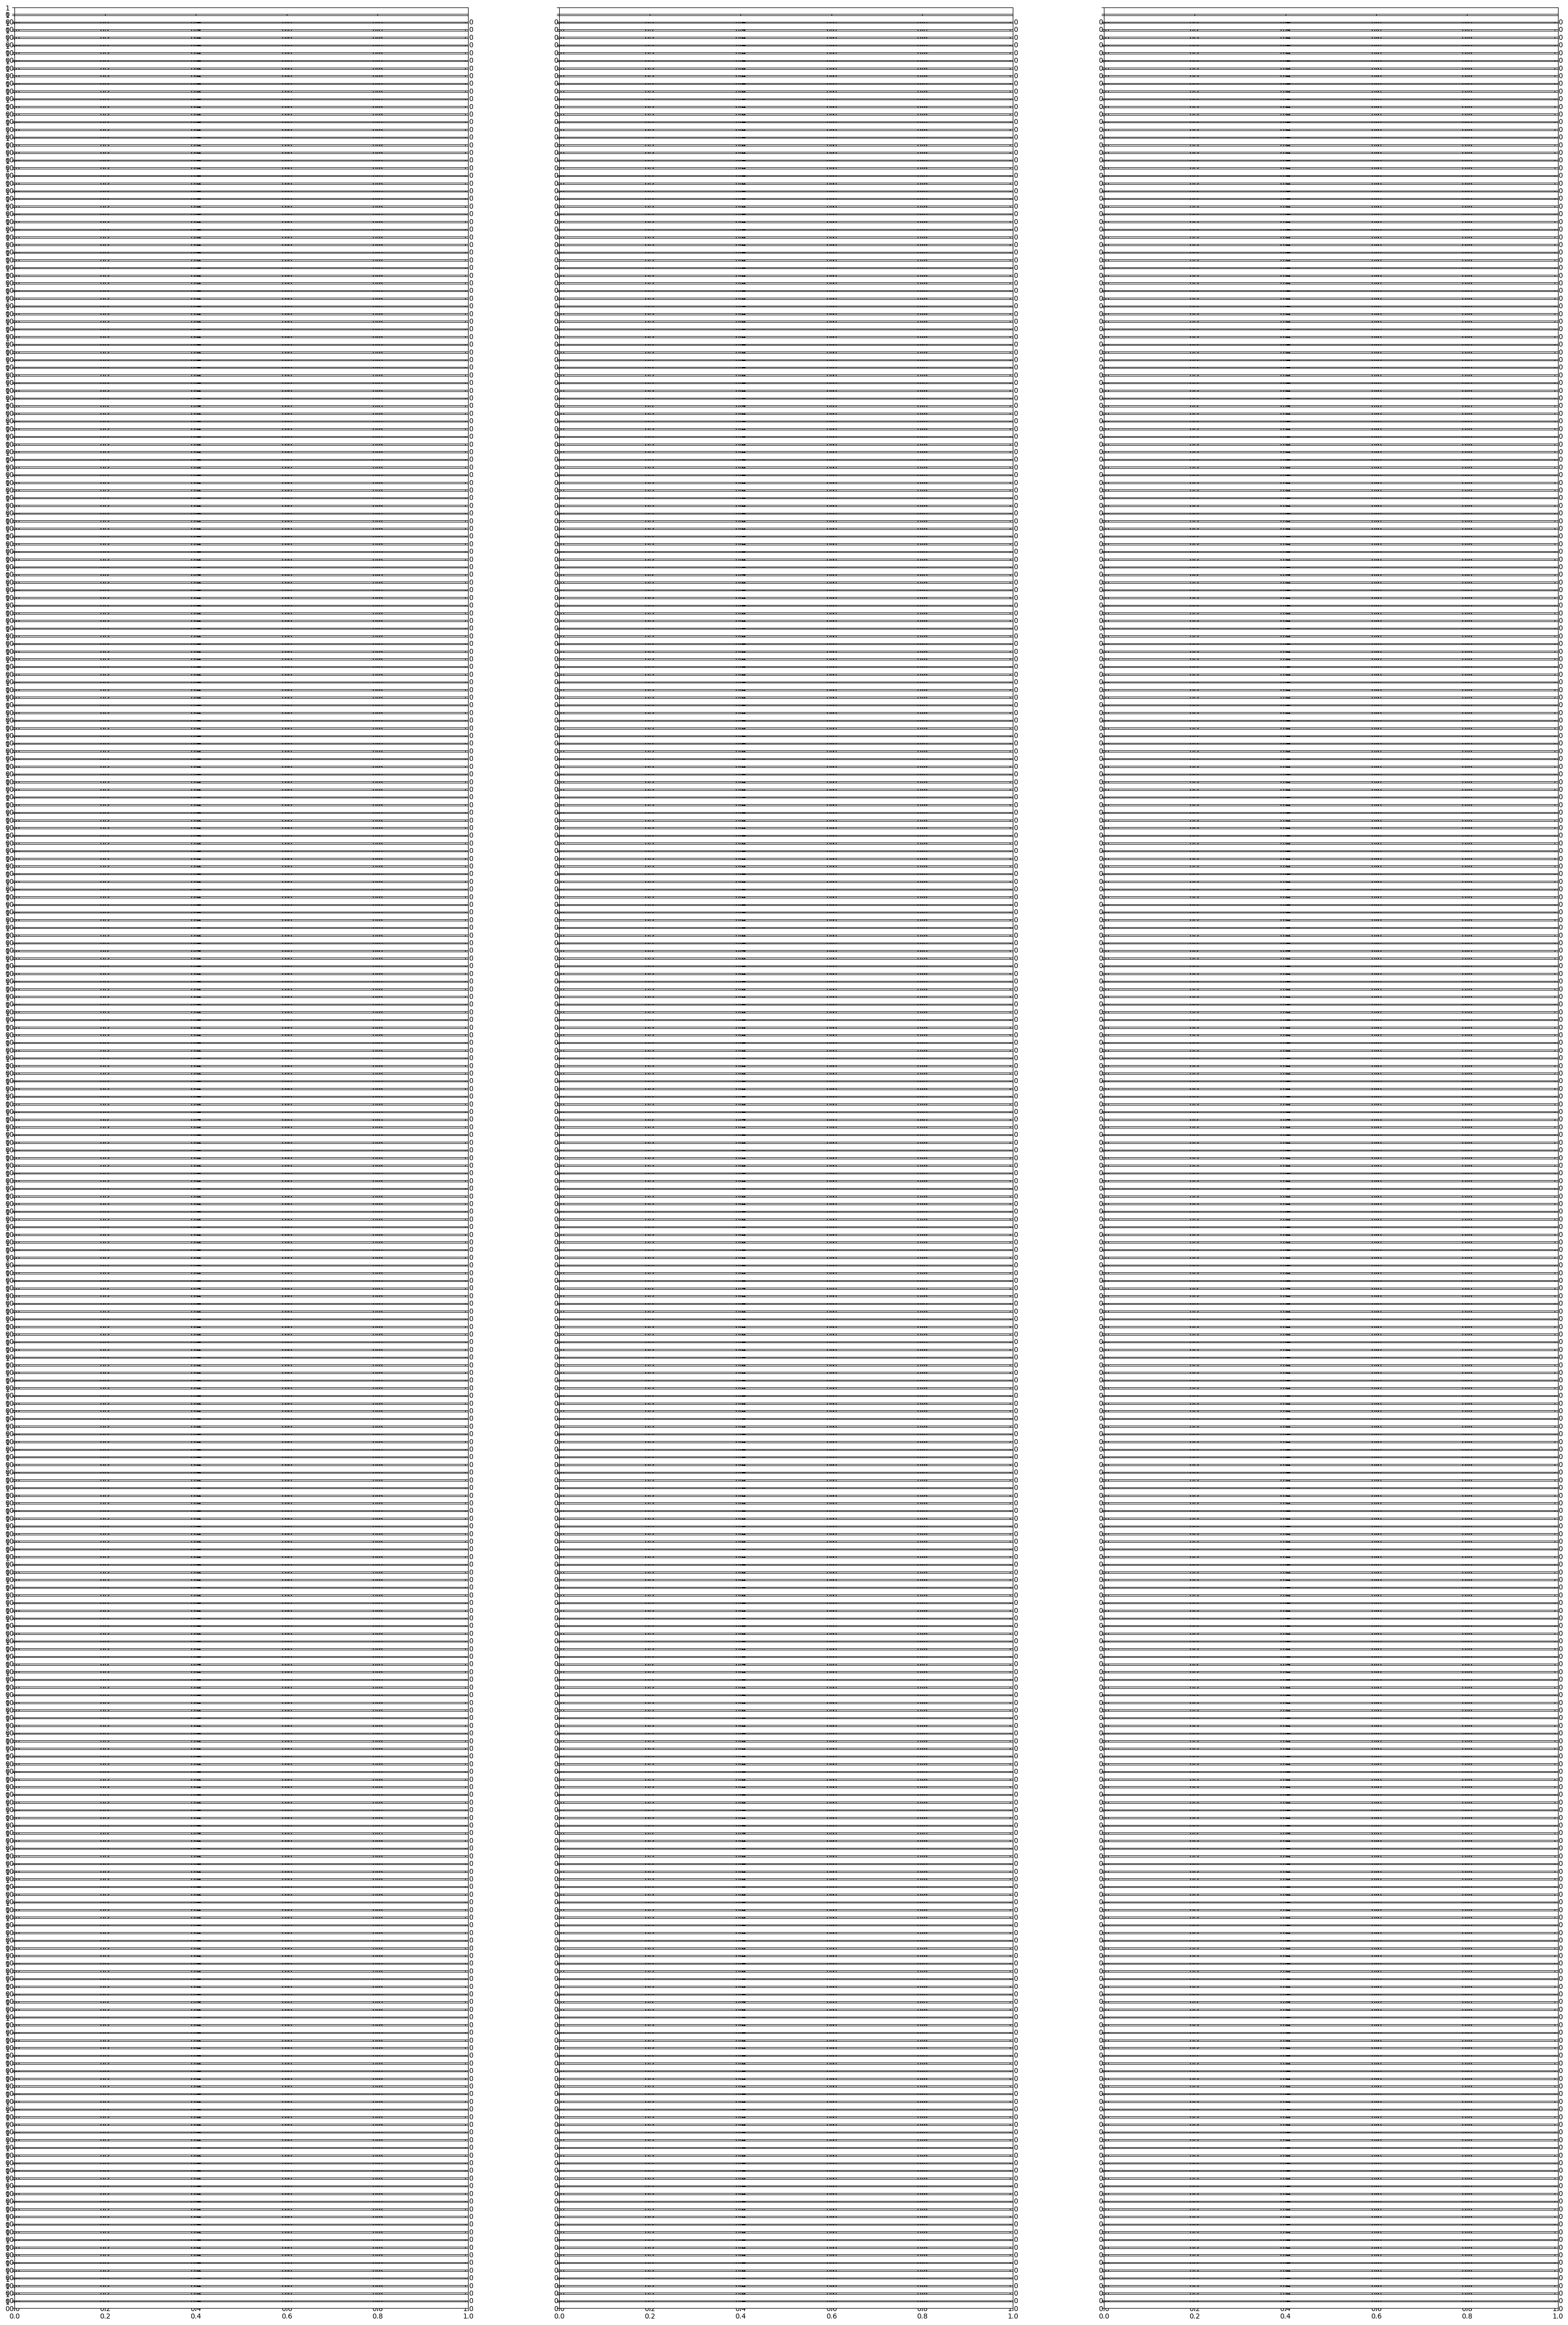

In [33]:
N_ROUNDS = 128
N_PRIOR = 32
L=0.

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(40, 60), sharey=True)
axes = axes.flatten()

called_arms = [set() for _ in range(len(SEEDS))]
igd, cost_regrets, all_avg_regret = [], [], []
calls = 0
model_labels = [f'arm_{i}' for i in range(N_ARMS)]

f1s=[]
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    alpha = np.ones(N_ARMS)
    beta = np.ones(N_ARMS)
    regrets = []
    optimal_prob = true_probs.max()

    # Prior phase
    for _ in range(N_PRIOR):
        success_vec = np.random.binomial(1, true_probs)
        alpha += success_vec
        beta += 1 - success_vec
        regrets.extend(optimal_prob - true_probs)
        cost_regrets.extend(arm_costs * (optimal_prob - true_probs))
        called_arms[idx].update(range(N_ARMS))
        calls += N_ARMS

    # TS main loop
    for _ in range(N_ROUNDS - N_PRIOR):
        theta = sample_ts_theta(alpha, beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)
        calls += 1

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({'Cost': arm_costs, 'Score': est_probs, 'Model': model_labels})
    true_df = pd.DataFrame({'Cost': arm_costs, 'Score': true_probs, 'Model': model_labels})

    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))

    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)

#     plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
#     ax.set_title(f"Seed {seed}")
#     ax.set_xlabel("Arm Cost")
#     if idx % N_COLS == 0:
#         ax.set_ylabel("Estimated Success Probability")
    

# for j in range(len(SEEDS), len(axes)):
#     fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)
# fig.suptitle("Pareto Frontiers with Thompson Sampling", fontsize=40)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()

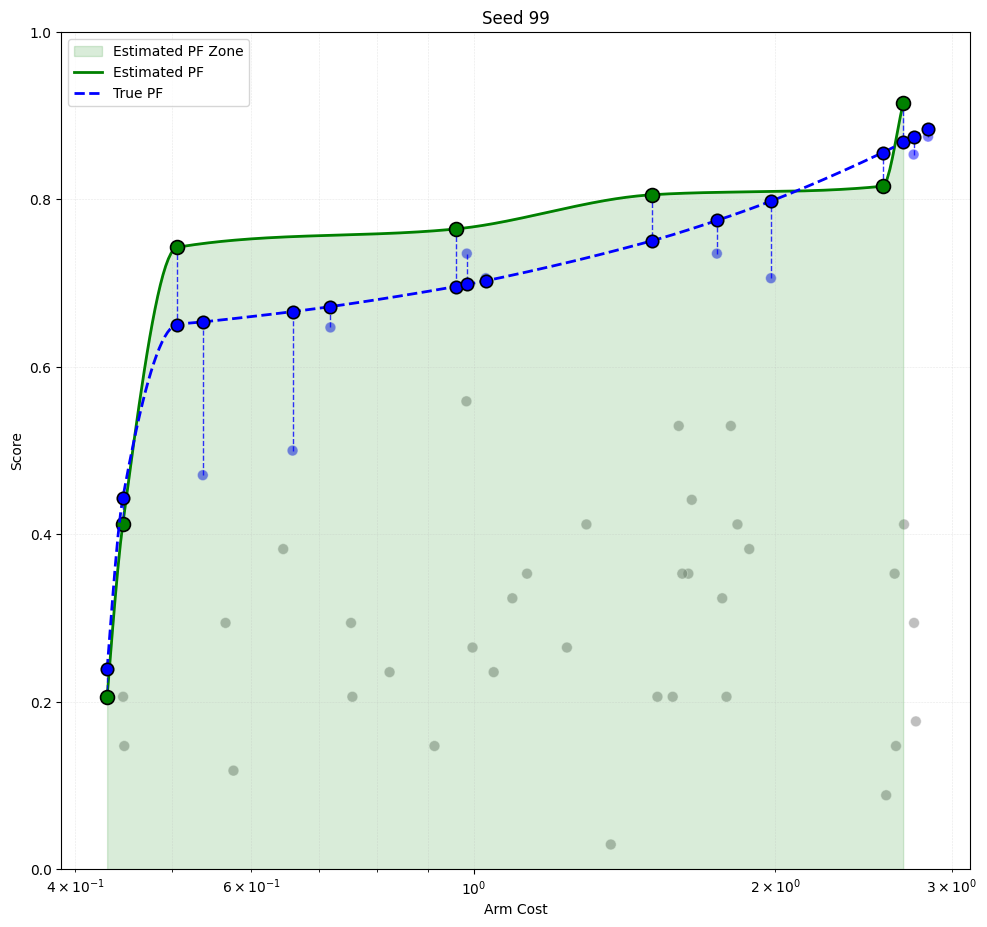

In [34]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [35]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 1696
Average distinct arms called per seed: 50.00
Pareto quality (mean IGD): 0.1481
Average regret per pull: 0.4247
Average cost regret per pull: 0.5779
Average F1 Score:  0.5928


# Thompson Sampling (Prior Size = 8)
---

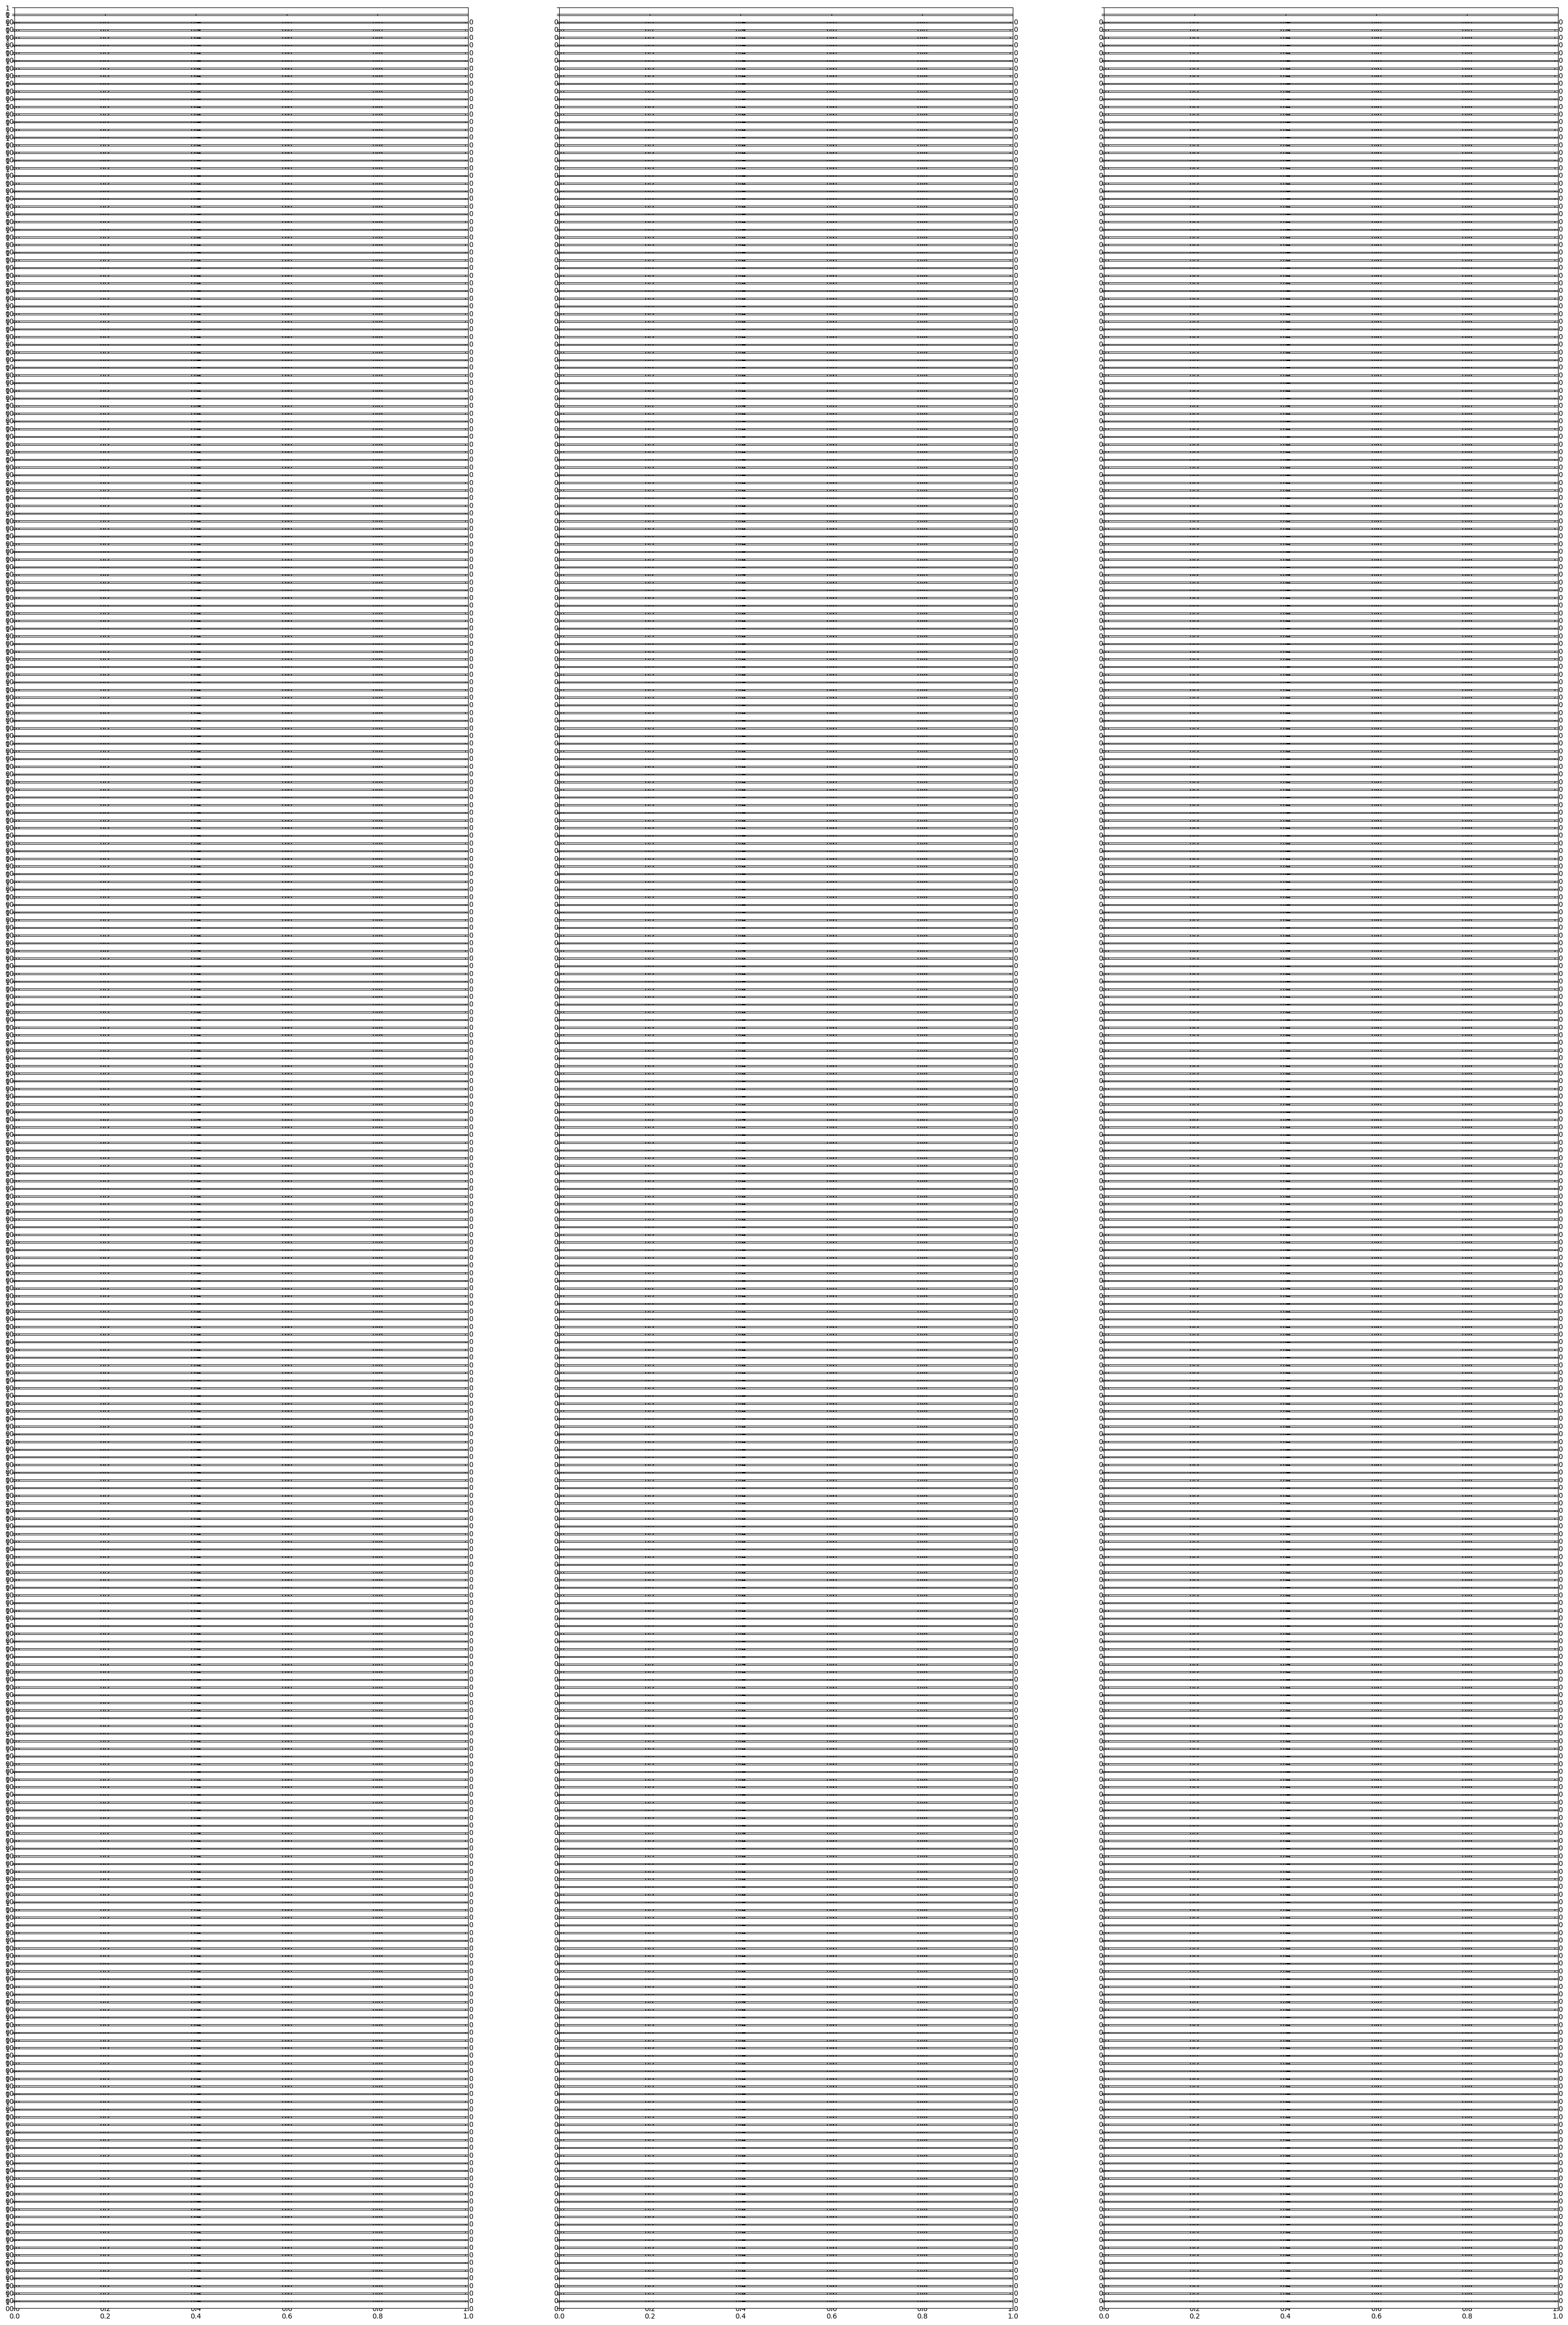

In [7]:
N_ROUNDS = 128
N_PRIOR = 8
L=0.

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(40, 60), sharey=True)
axes = axes.flatten()

called_arms = [set() for _ in range(len(SEEDS))]
igd, cost_regrets, all_avg_regret = [], [], []
calls = 0
model_labels = [f'arm_{i}' for i in range(N_ARMS)]

f1s=[]
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    alpha = np.ones(N_ARMS)
    beta = np.ones(N_ARMS)
    regrets = []
    optimal_prob = true_probs.max()

    # Prior phase
    for _ in range(N_PRIOR):
        success_vec = np.random.binomial(1, true_probs)
        alpha += success_vec
        beta += 1 - success_vec
        regrets.extend(optimal_prob - true_probs)
        cost_regrets.extend(arm_costs * (optimal_prob - true_probs))
        called_arms[idx].update(range(N_ARMS))
        calls += N_ARMS

    # TS main loop
    for _ in range(N_ROUNDS - N_PRIOR):
        theta = sample_ts_theta(alpha, beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)
        calls += 1

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({'Cost': arm_costs, 'Score': est_probs, 'Model': model_labels})
    true_df = pd.DataFrame({'Cost': arm_costs, 'Score': true_probs, 'Model': model_labels})

    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))

    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)

#     plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
#     ax.set_title(f"Seed {seed}")
#     ax.set_xlabel("Arm Cost")
#     if idx % N_COLS == 0:
#         ax.set_ylabel("Estimated Success Probability")
    

# for j in range(len(SEEDS), len(axes)):
#     fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)
# fig.suptitle("Pareto Frontiers with Thompson Sampling", fontsize=40)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()

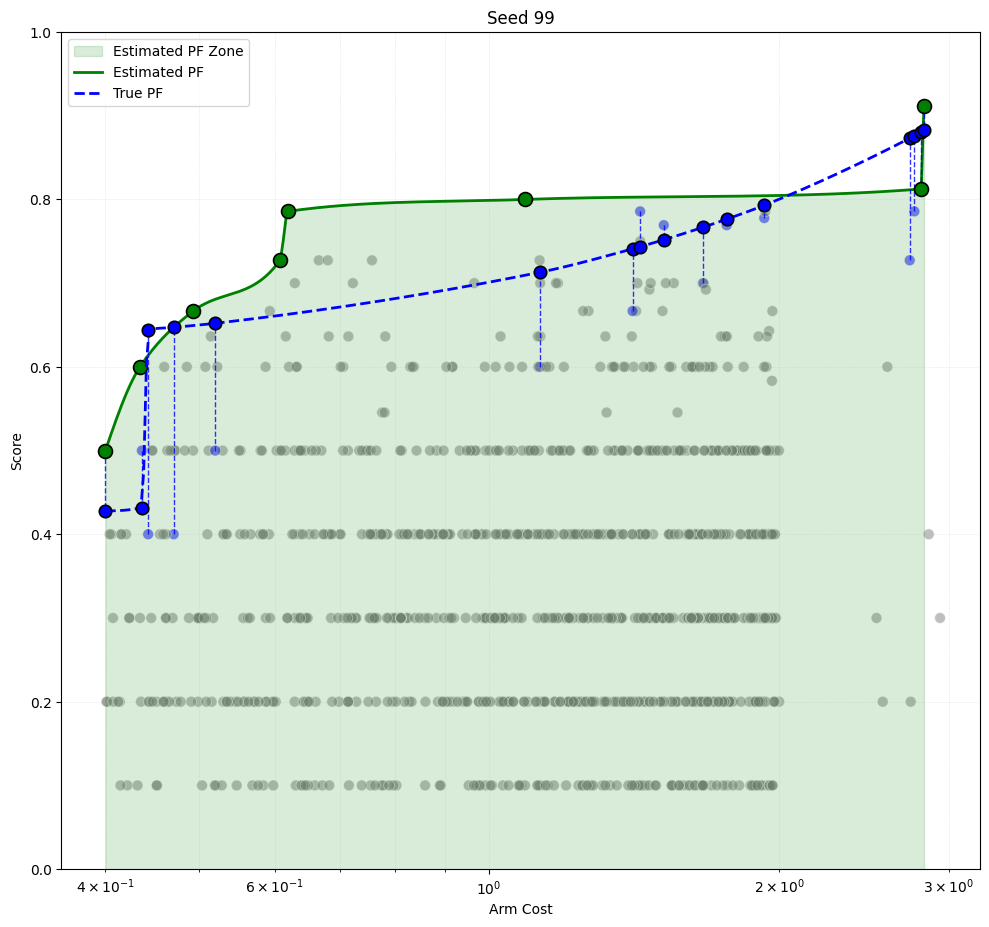

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [9]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 8120
Average distinct arms called per seed: 1000.00
Pareto quality (mean IGD): 0.2282
Average regret per pull: 0.5732
Average cost regret per pull: 0.6975
Average F1 Score:  0.3561


# Thompson Sampling (Prior Size = 0)
---

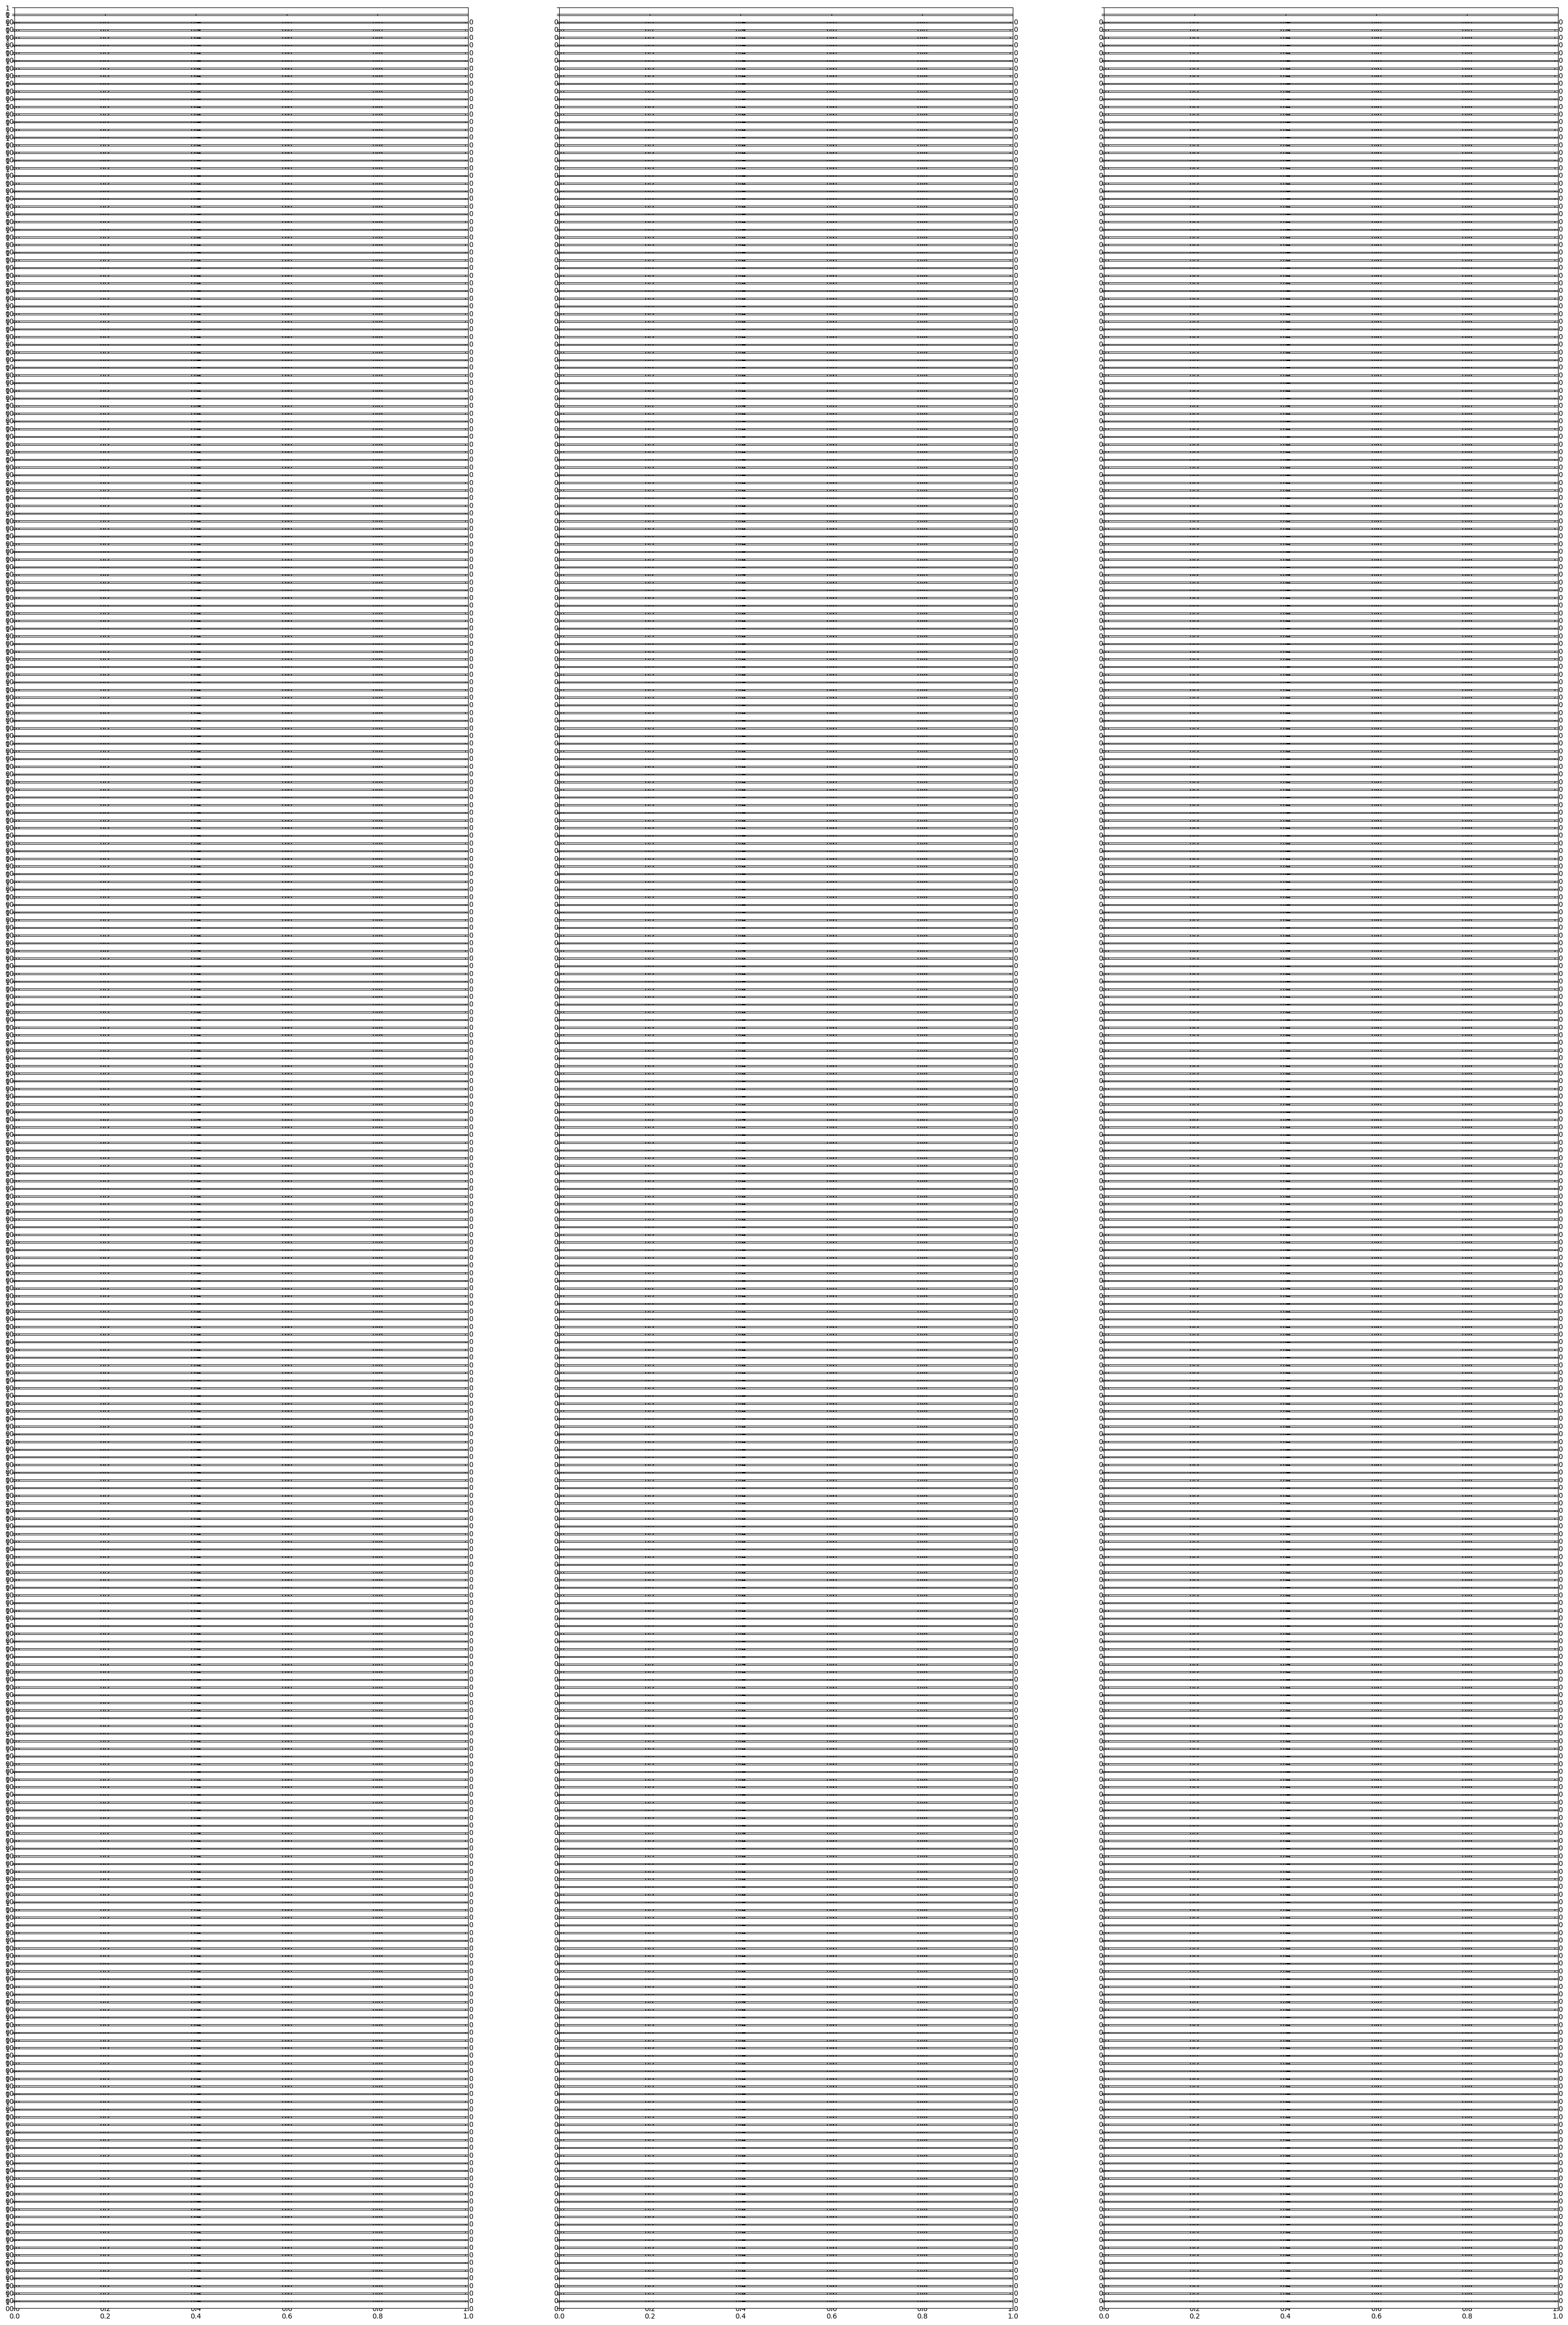

In [10]:
N_ROUNDS = 128
N_PRIOR = 0
L=0.

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(40, 60), sharey=True)
axes = axes.flatten()

called_arms = [set() for _ in range(len(SEEDS))]
igd, cost_regrets, all_avg_regret = [], [], []
calls = 0
model_labels = [f'arm_{i}' for i in range(N_ARMS)]

f1s=[]
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    alpha = np.ones(N_ARMS)
    beta = np.ones(N_ARMS)
    regrets = []
    optimal_prob = true_probs.max()

    # Prior phase
    for _ in range(N_PRIOR):
        success_vec = np.random.binomial(1, true_probs)
        alpha += success_vec
        beta += 1 - success_vec
        regrets.extend(optimal_prob - true_probs)
        cost_regrets.extend(arm_costs * (optimal_prob - true_probs))
        called_arms[idx].update(range(N_ARMS))
        calls += N_ARMS

    # TS main loop
    for _ in range(N_ROUNDS - N_PRIOR):
        theta = sample_ts_theta(alpha, beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)
        calls += 1

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({'Cost': arm_costs, 'Score': est_probs, 'Model': model_labels})
    true_df = pd.DataFrame({'Cost': arm_costs, 'Score': true_probs, 'Model': model_labels})

    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))

    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)

#     plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
#     ax.set_title(f"Seed {seed}")
#     ax.set_xlabel("Arm Cost")
#     if idx % N_COLS == 0:
#         ax.set_ylabel("Estimated Success Probability")
    

# for j in range(len(SEEDS), len(axes)):
#     fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)
# fig.suptitle("Pareto Frontiers with Thompson Sampling", fontsize=40)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()

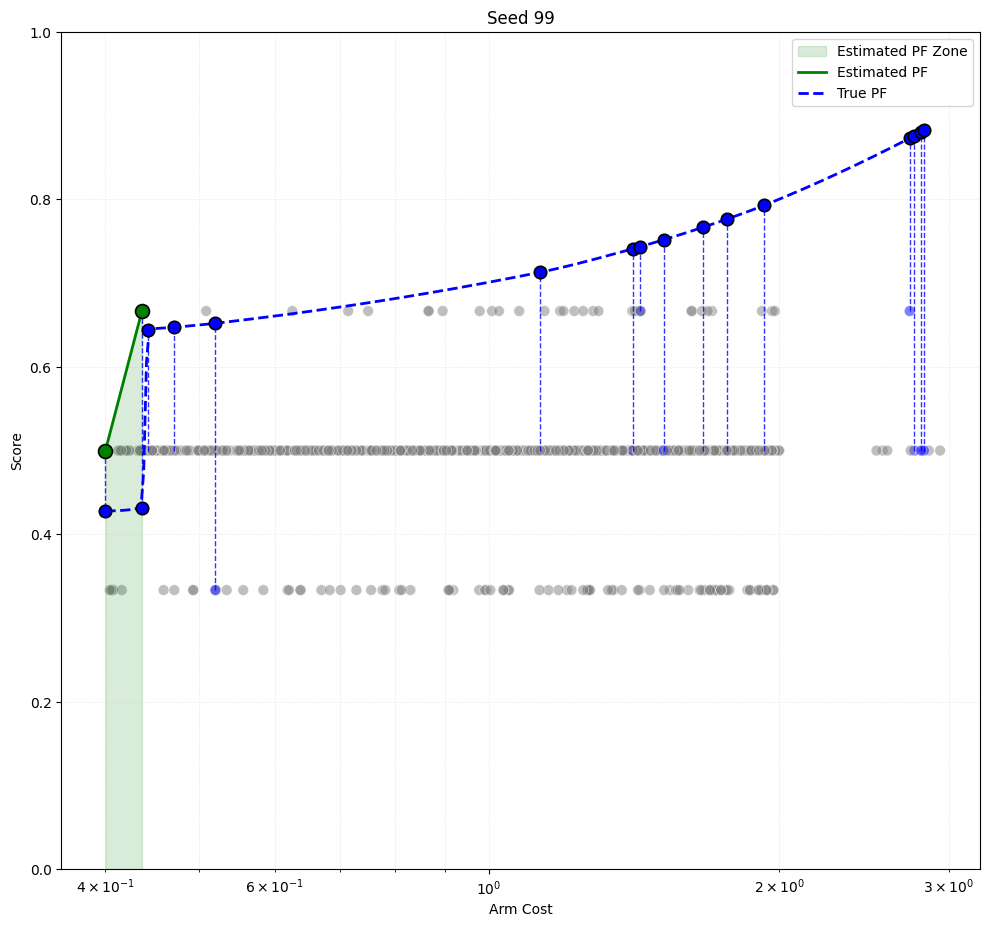

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [12]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 128
Average distinct arms called per seed: 123.60
Pareto quality (mean IGD): 0.7484
Average regret per pull: 0.5760
Average cost regret per pull: 0.6998
Average F1 Score:  0.1092


# Shared Prior Thompson Sampling (High Uncertainity on shared prior, w = 0.3)
---


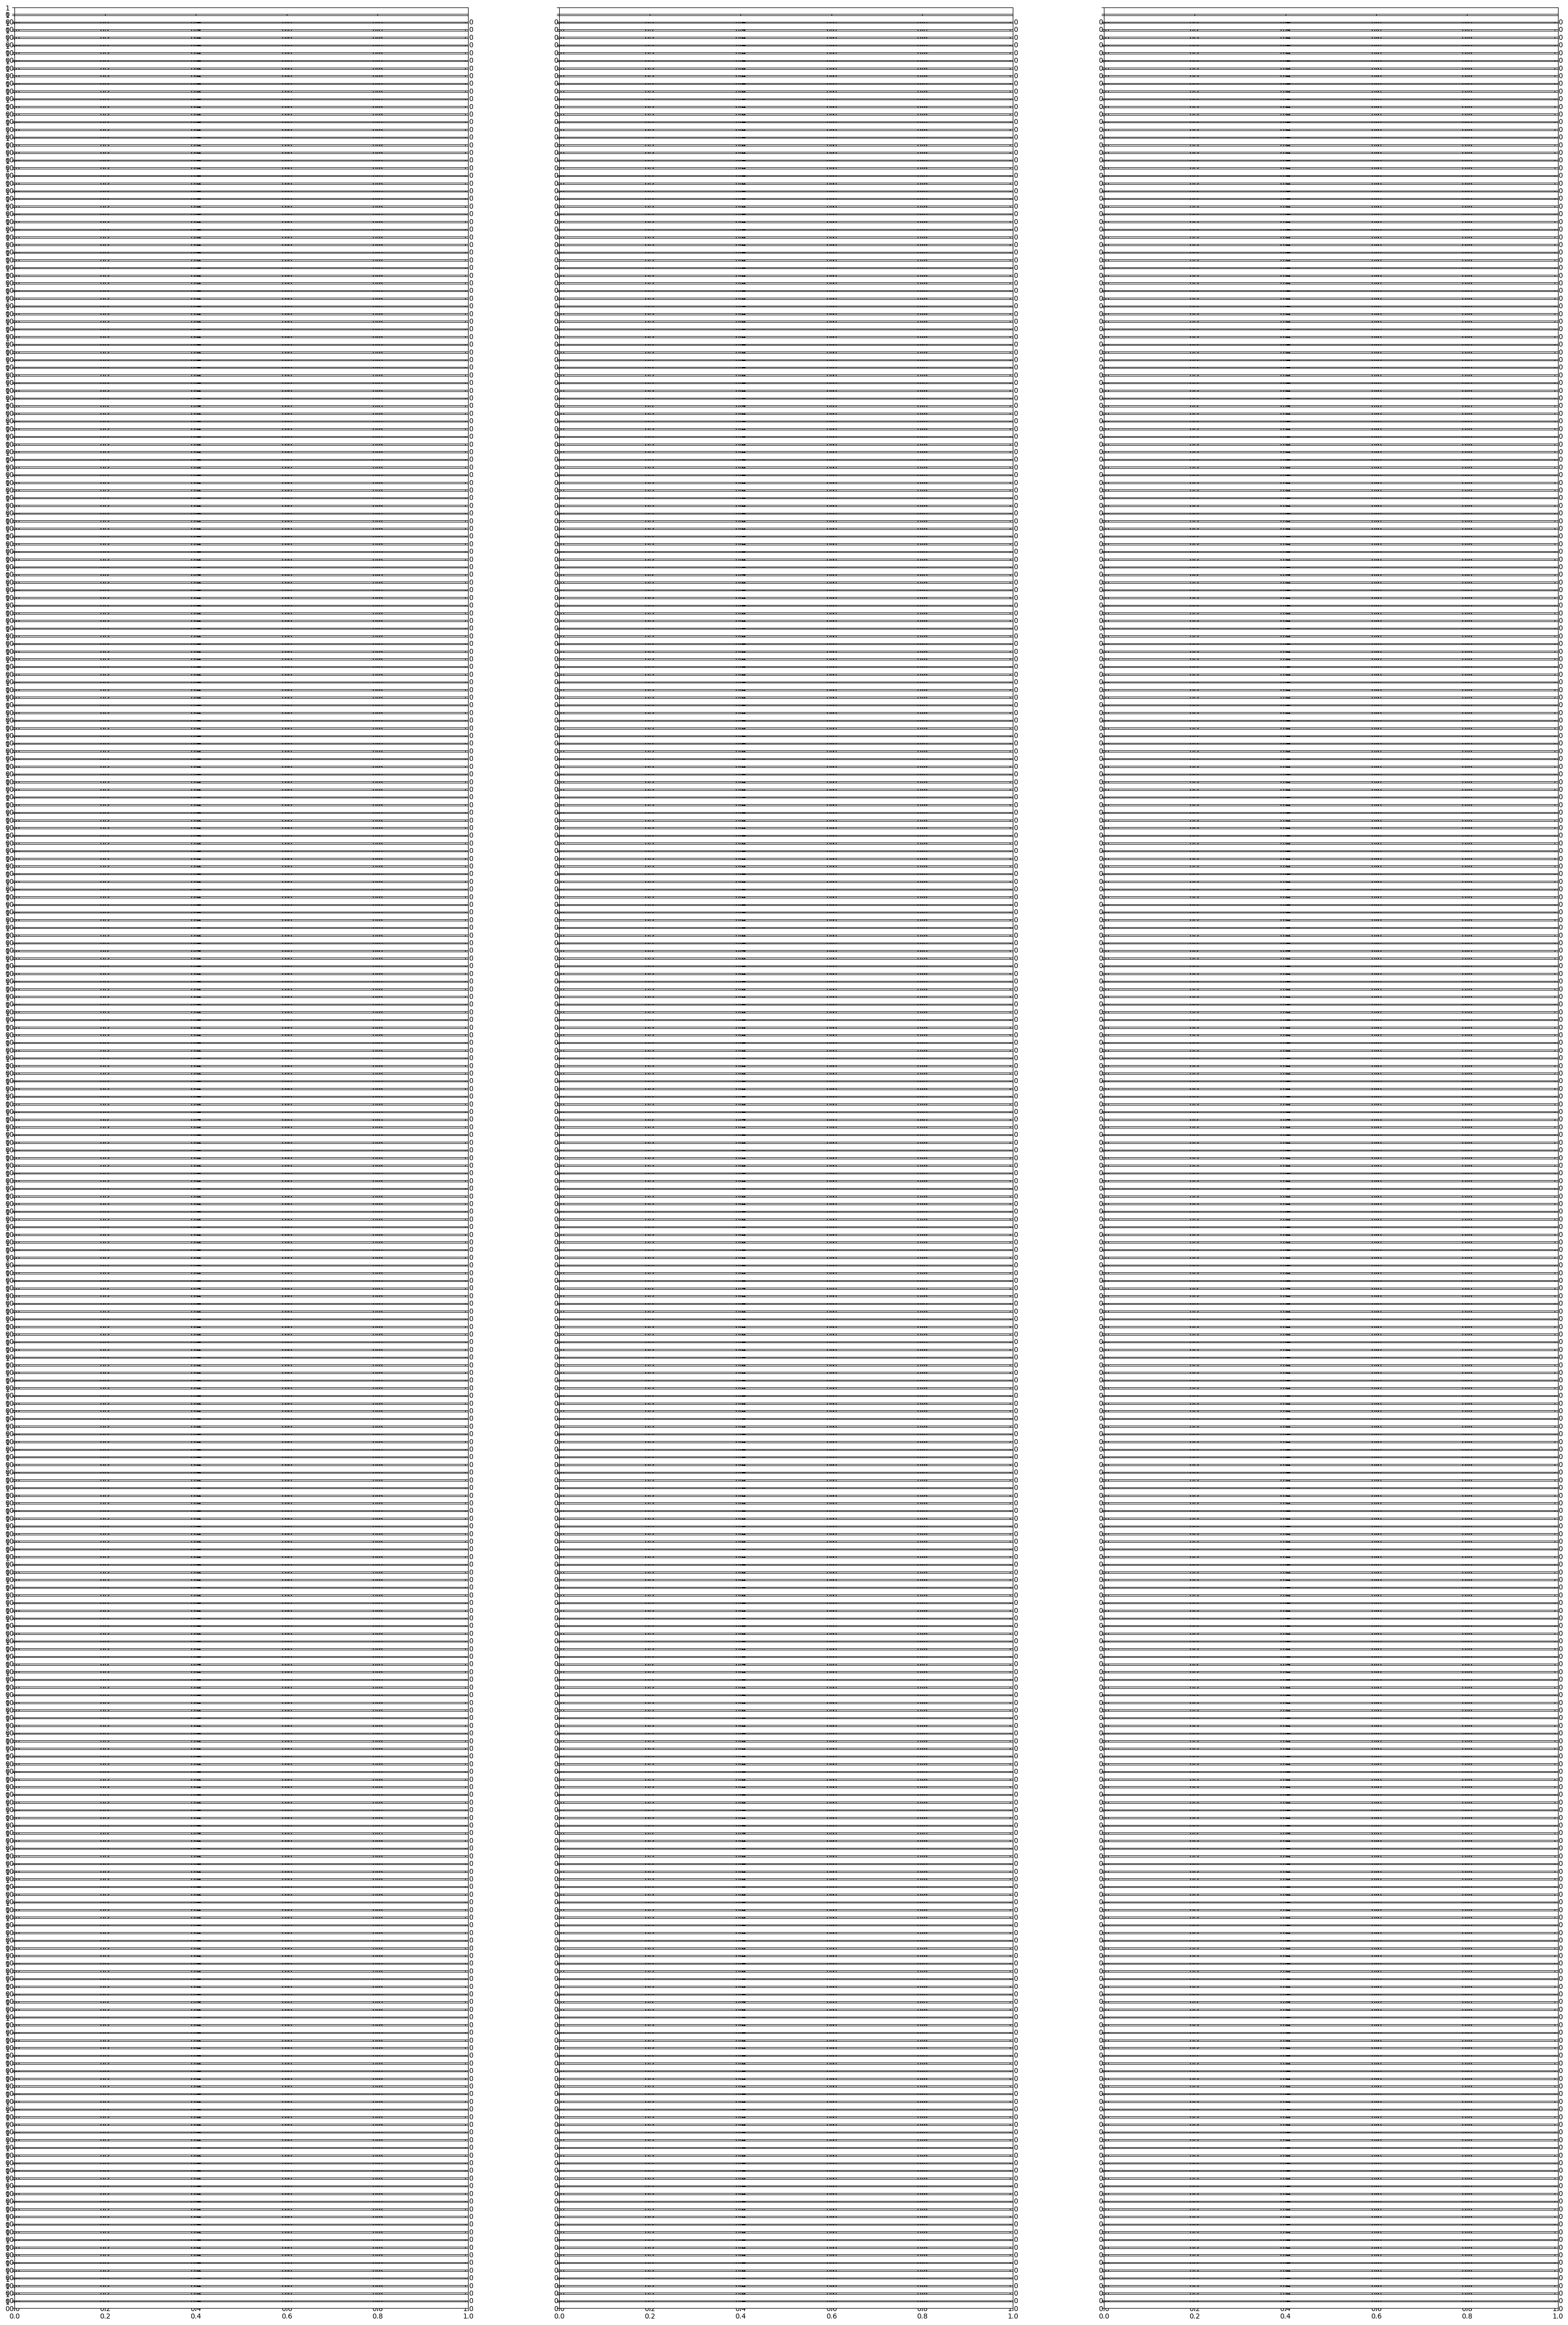

In [91]:
N_ROUNDS = 128
N_PRIOR = 0
W = 0.3
LR = 0.2
L = 0
# --------- Plot Setup ---------
n_cols = N_COLS
n_rows = N_ROWS
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 60), sharey=True)
axes = axes.flatten()

galpha = np.ones(N_ARMS)
gbeta = np.ones(N_ARMS)
calls = 0
igd = []
cost_regrets = []
all_avg_regret = []
called_arms = [set() for _ in range(len(SEEDS))]
model_labels = [f'arm_{i}' for i in range(N_ARMS)]
f1s = []
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    
    
    alpha =  W * galpha.copy() 
    beta =  W * gbeta.copy() 

    preva = alpha.copy()
    prevb = beta.copy()

    regrets = []
    optimal_prob = true_probs.max()

    for _ in range(N_ROUNDS):
        theta = sample_ts_theta(alpha,beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        calls += 1

        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({
        'Cost': arm_costs,
        'Score': est_probs,
        'Model': model_labels
    })

    true_df = pd.DataFrame({
        'Cost': arm_costs,
        'Score': true_probs,
        'Model': model_labels
    })

    fPareto = get_fPareto_function(compute_pareto(data, 'Cost', 'Score'))
    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))
    
    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives



    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)
    
    galpha += (alpha-preva) 
    gbeta  += (beta-prevb)


    # plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
    # ax.set_title(f"Seed {seed}")
    # ax.set_xlabel("Arm Cost")
    # if idx % n_cols == 0:
    #     ax.set_ylabel("Estimated Success Probability")
    # ax.legend()

# Remove unused subplots
for j in range(len(SEEDS), len(axes)):
    fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)

# fig.suptitle("Pareto Frontiers with Meta Prior Thompson Sampling", fontsize=40)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()


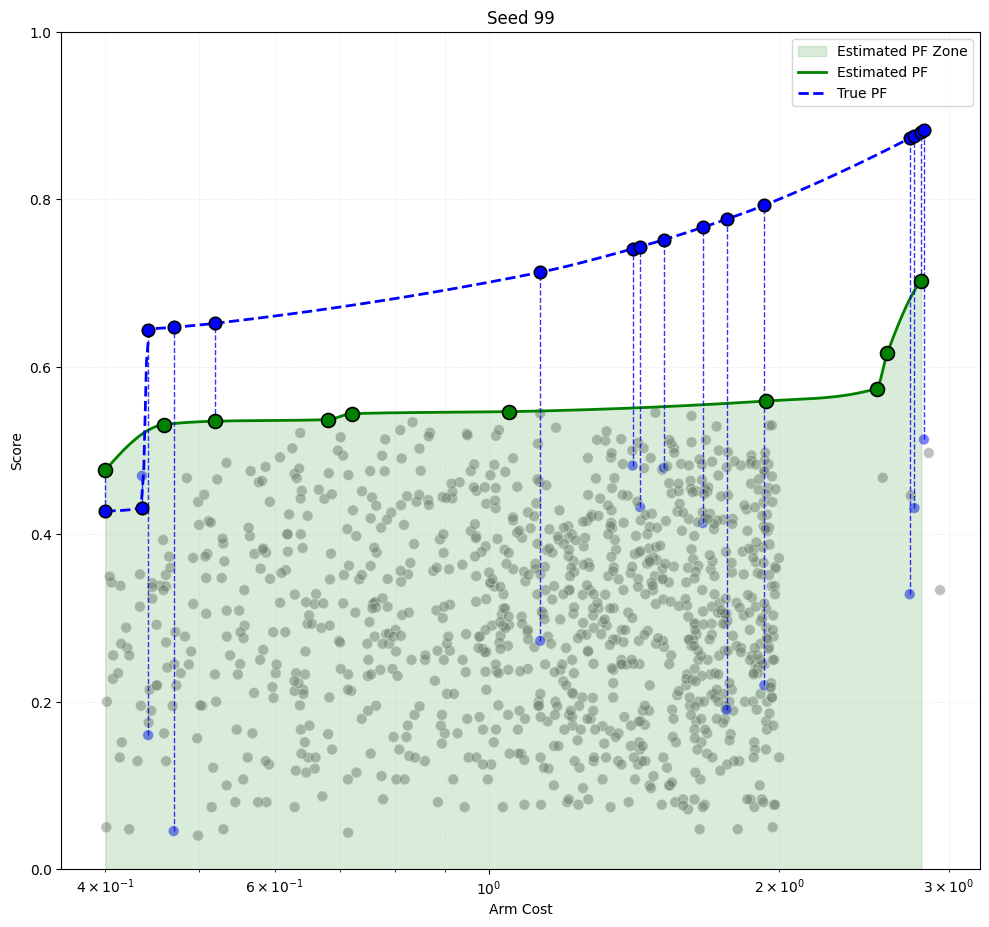

In [102]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [15]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 128
Average distinct arms called per seed: 75.88
Pareto quality (mean IGD): 0.2446
Average regret per pull: 0.3955
Average cost regret per pull: 0.5927
Average F1 Score:  0.2505


# Shared Prior Thompson Sampling (High depedency on shared prior, w = 0.7)
---


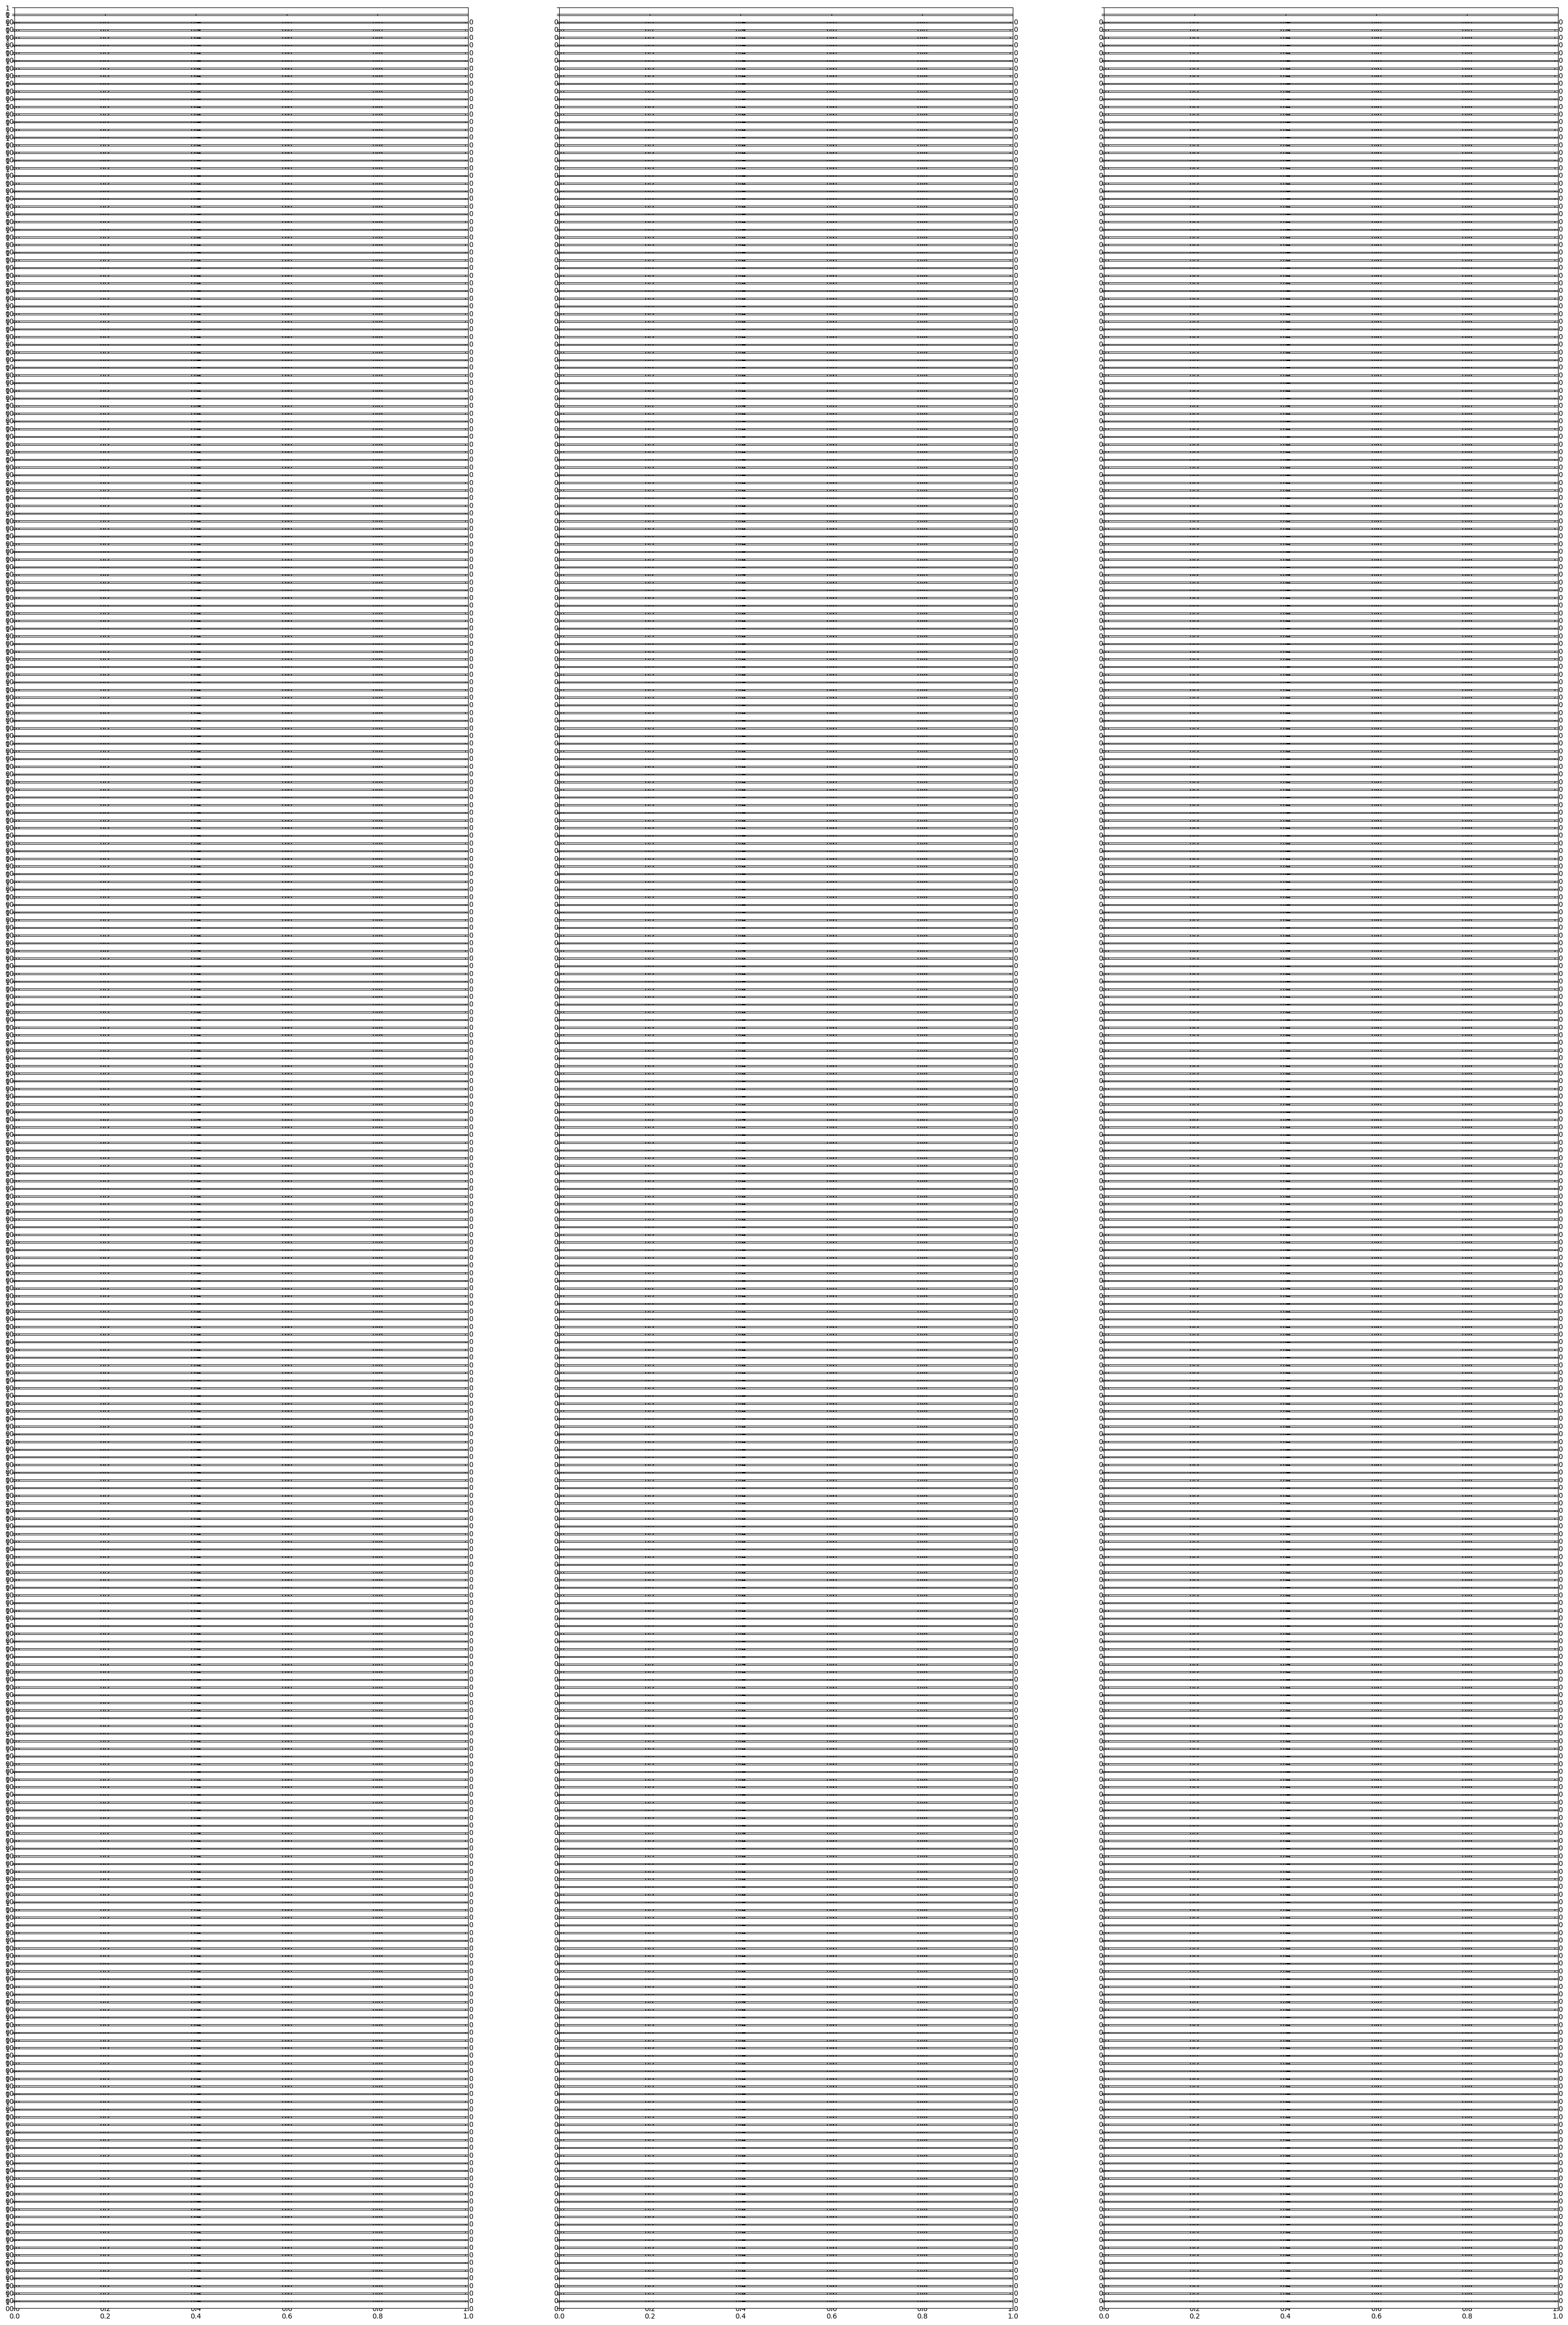

In [16]:
N_ROUNDS = 128
N_PRIOR = 0
W = 0.7
LR = 0.2
# --------- Plot Setup ---------
n_cols = N_COLS
n_rows = N_ROWS
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 60), sharey=True)
axes = axes.flatten()

galpha = np.ones(N_ARMS)
gbeta = np.ones(N_ARMS)
calls = 0
igd = []
cost_regrets = []
all_avg_regret = []
called_arms = [set() for _ in range(len(SEEDS))]
model_labels = [f'arm_{i}' for i in range(N_ARMS)]
f1s = []
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    
    
    alpha =  W * galpha.copy() 
    beta =  W * gbeta.copy() 

    preva = alpha.copy()
    prevb = beta.copy()

    regrets = []
    optimal_prob = true_probs.max()

    for _ in range(N_ROUNDS):
        theta = sample_ts_theta(alpha,beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        calls += 1

        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({
        'Cost': arm_costs,
        'Score': est_probs,
        'Model': model_labels
    })

    true_df = pd.DataFrame({
        'Cost': arm_costs,
        'Score': true_probs,
        'Model': model_labels
    })

    fPareto = get_fPareto_function(compute_pareto(data, 'Cost', 'Score'))
    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))
    
    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives



    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)
    
    galpha += (alpha-preva)  
    gbeta  += (beta-prevb) 


#     plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
#     ax.set_title(f"Seed {seed}")
#     ax.set_xlabel("Arm Cost")
#     if idx % n_cols == 0:
#         ax.set_ylabel("Estimated Success Probability")
#     ax.legend()

# # Remove unused subplots
# for j in range(len(SEEDS), len(axes)):
#     fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)

# fig.suptitle("Pareto Frontiers with Meta Prior Thompson Sampling", fontsize=40)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()

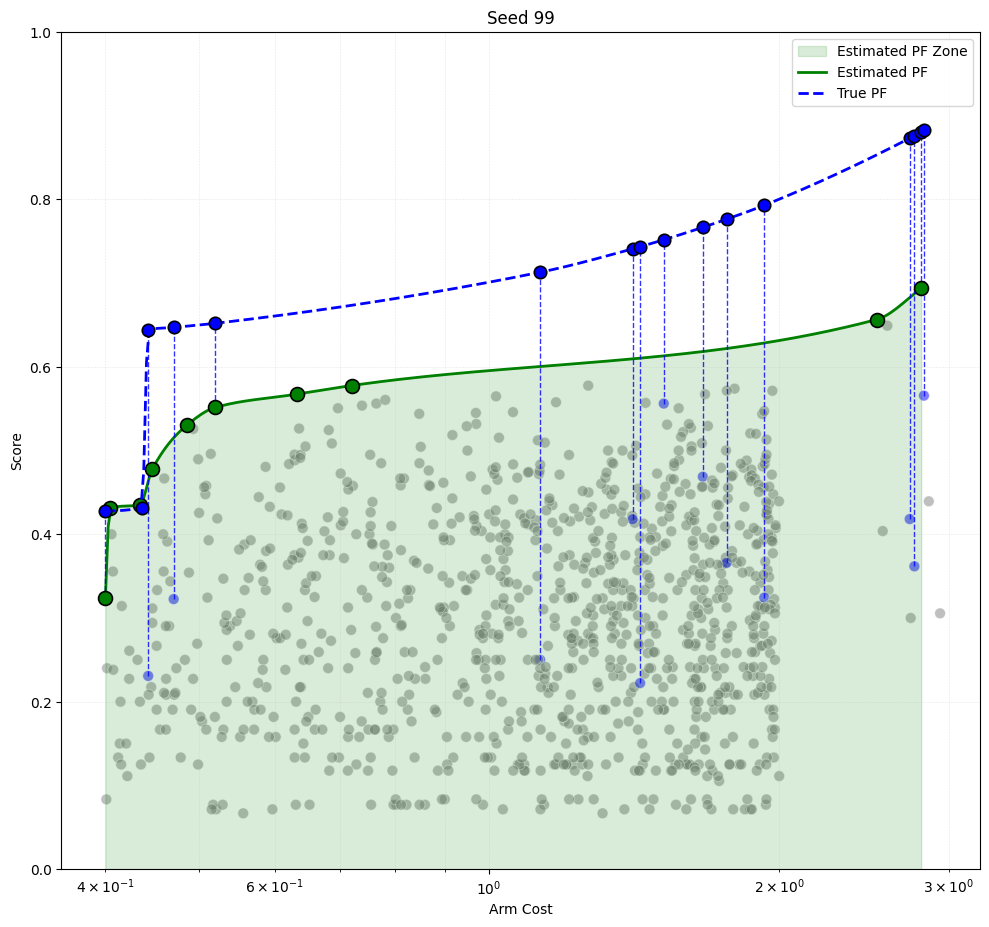

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [18]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 128
Average distinct arms called per seed: 43.17
Pareto quality (mean IGD): 0.2575
Average regret per pull: 0.3074
Average cost regret per pull: 0.5729
Average F1 Score:  0.2302


# Shared Prior Thompson Sampling (Ablation test w = 1.)
---


IndexError: index 30 is out of bounds for axis 0 with size 30

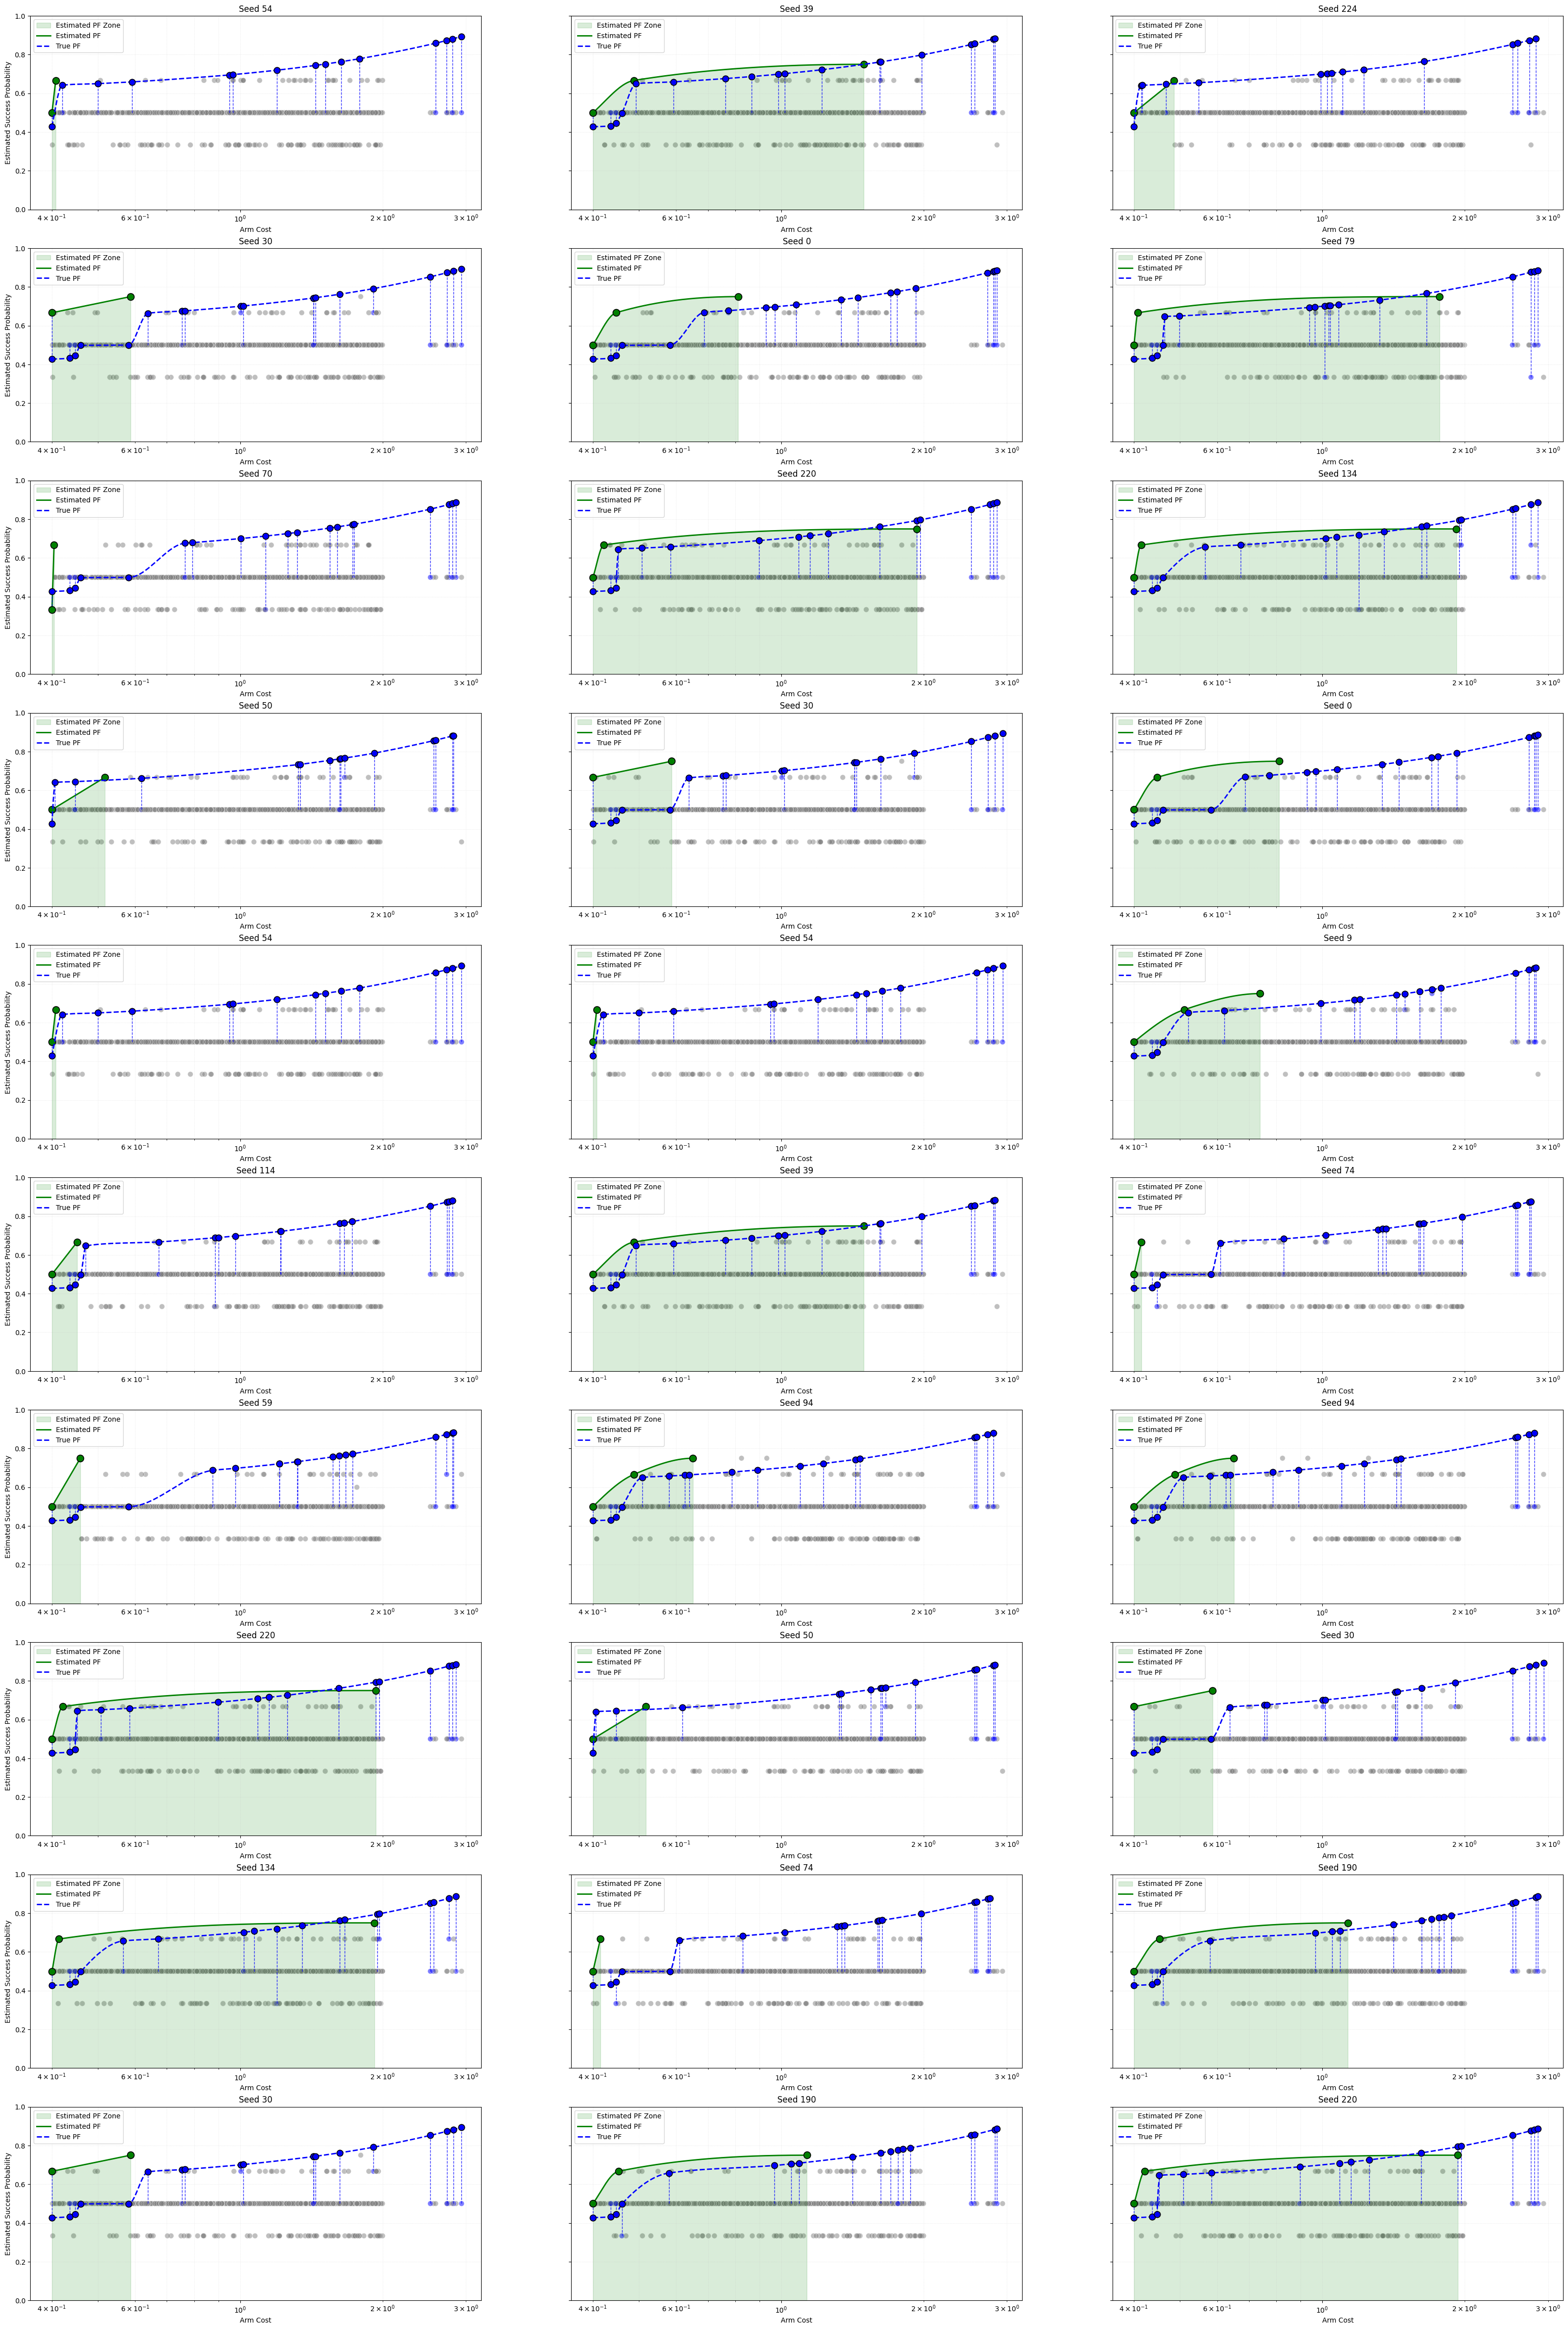

In [19]:
N_ROUNDS = 128
N_PRIOR = 0
W = 1.
L = 0.0
# --------- Plot Setup ---------
n_cols = 3
n_rows = 10
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 60), sharey=True)
axes = axes.flatten()

galpha = np.ones(N_ARMS)
gbeta = np.ones(N_ARMS)
calls = 0
igd = []
cost_regrets = []
all_avg_regret = []
called_arms = [set() for _ in range(len(SEEDS))]
model_labels = [f'arm_{i}' for i in range(N_ARMS)]
f1s = []
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    
    
    alpha =  W * np.ones(N_ARMS) + (1-W) * galpha.copy()
    beta =  W * np.ones(N_ARMS) + (1-W) * gbeta.copy()

    preva = alpha.copy()
    prevb = beta.copy()

    regrets = []
    optimal_prob = true_probs.max()

    for _ in range(N_ROUNDS):
        theta = sample_ts_theta(alpha,beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        calls += 1

        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({
        'Cost': arm_costs,
        'Score': est_probs,
        'Model': model_labels
    })

    true_df = pd.DataFrame({
        'Cost': arm_costs,
        'Score': true_probs,
        'Model': model_labels
    })

    fPareto = get_fPareto_function(compute_pareto(data, 'Cost', 'Score'))
    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))
    
    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives



    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)
    
    galpha += (alpha-preva)  *LR
    gbeta  += (beta-prevb) *LR


    plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Arm Cost")
    if idx % n_cols == 0:
        ax.set_ylabel("Estimated Success Probability")
    ax.legend()

# Remove unused subplots
for j in range(len(SEEDS), len(axes)):
    fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)

fig.suptitle("Pareto Frontiers with Meta Prior Thompson Sampling", fontsize=40)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

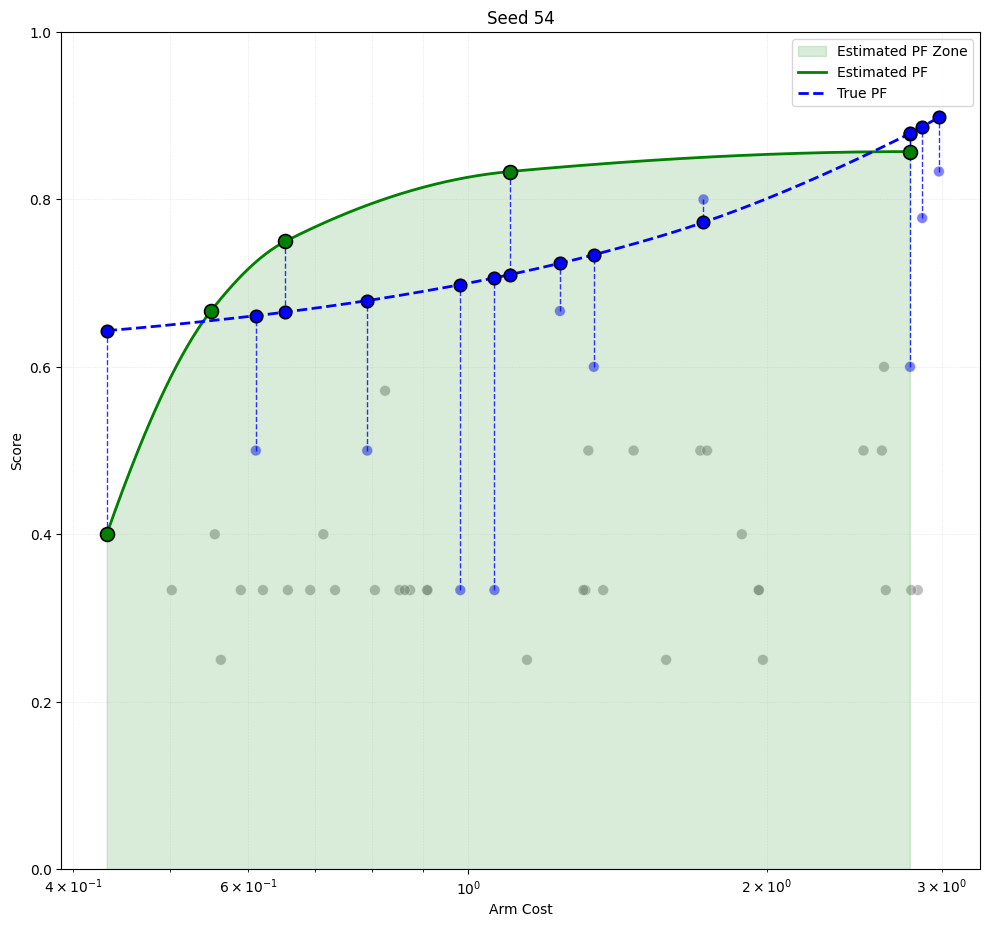

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 128
Average distinct arms called per seed: 48.70
Pareto quality (mean IGD): 0.3721
Average regret per pull: 0.3184
Average cost regret per pull: 0.4119
Average F1 Score:  0.3816


# Y (w=0.3)

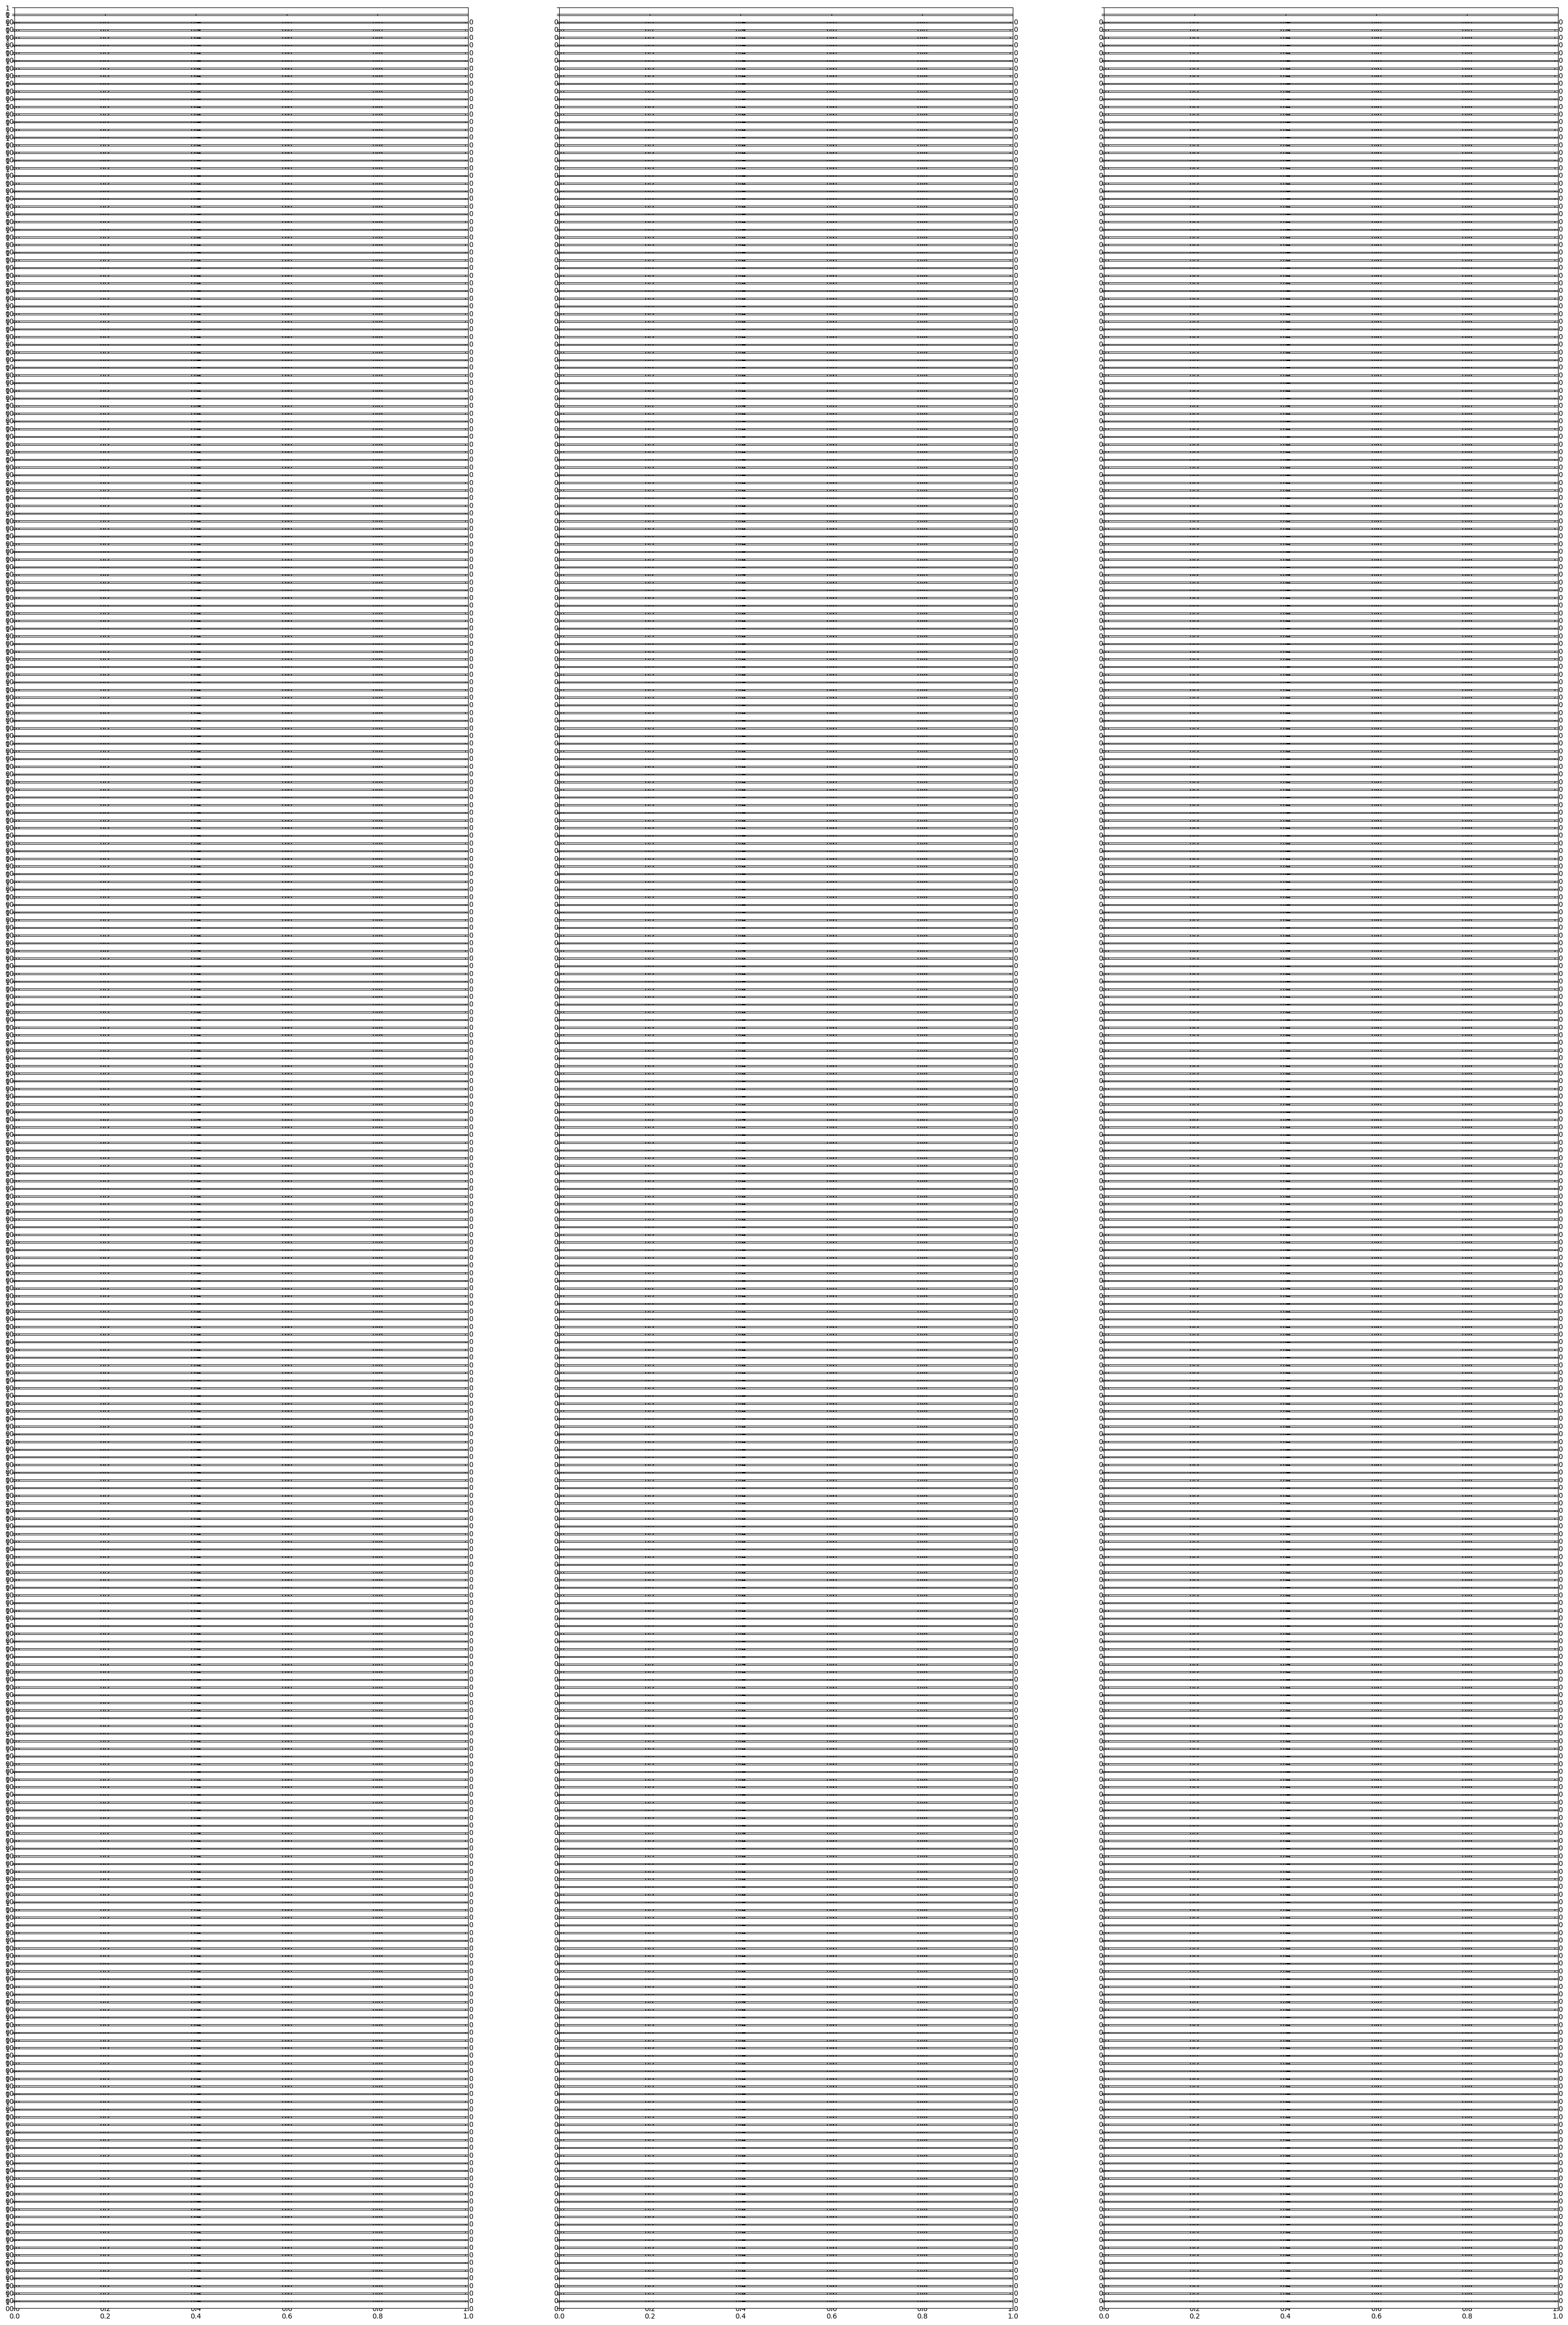

In [14]:
import itertools

N_ROUNDS = 128
N_PRIOR = 0
W = 0.1

# --------- Plot Setup ---------
n_cols = N_COLS
n_rows = N_ROWS
fig, axes = plt.subplots(n_rows, n_cols, figsize=(40, 60), sharey=True)
axes = axes.flatten()

galpha = np.ones((N_ARMS,11,11))
gbeta = np.ones((N_ARMS,11,11))
calls = 0
igd = []
cost_regrets = []
all_avg_regret = []
called_arms = [set() for _ in range(len(SEEDS))]
model_labels = [f'arm_{i}' for i in range(N_ARMS)]
f1s = []
for idx, seed in enumerate(SEEDS):
    np.random.seed(seed)
    ax = axes[idx]

    true_probs = np.linspace(0.1, 0.5, N_ARMS)
    half_from_global = np.random.choice(global_good_indices, size=4, replace=False)
    true_probs[half_from_global] = GLOBAL_GOOD_PROB + arm_costs[half_from_global] * 0.1

    other_indices = np.setdiff1d(np.arange(N_ARMS), global_good_indices)
    local_other = np.random.choice(other_indices, size=10, replace=False)
    local_good_indices = np.concatenate((half_from_global, local_other))
    true_probs[local_good_indices] = LOCAL_GOOD_PROB +arm_costs[local_good_indices] * 0.1

    util = cluster_util[seed_to_cluster[seed]] if cluster_util[seed_to_cluster[seed]]  != [] else [0]
    cartesian = list(itertools.product(util, repeat=2)) 
    # unique_pairs = list({tuple(sorted(p)) for p in cartesian})
    unique_pairs = cartesian
    lalpha = np.array([np.sum([np.tril(galpha, k=0)[m][x] for x in unique_pairs]) for m in range(galpha.shape[0])])
    lbeta = np.array([np.sum([np.tril(gbeta, k=0)[m][x] for x in unique_pairs]) for m in range(gbeta.shape[0])])


    # alpha =  W * np.array(lalpha) 
    # beta =  W * np.array(lbeta) 

    n=lalpha+lbeta
    w = 1 - np.exp(-W * n)
    
    alpha =  w * np.array(lalpha) 
    beta =  w * np.array(lbeta) 
    preva = alpha.copy()
    prevb = beta.copy()

    regrets = []
    optimal_prob = true_probs.max()

    for _ in range(N_ROUNDS):
        theta = sample_ts_theta(alpha,beta)
        arm = np.argmax(theta)
        success = np.random.binomial(1, true_probs[arm])
        alpha[arm] += success
        beta[arm] += 1 - success
        calls += 1

        called_arms[idx].add(arm)
        regret = optimal_prob - true_probs[arm]
        regrets.append(regret)
        cost_regrets.append(arm_costs[arm] * regret)

    all_avg_regret.append(np.mean(regrets))

    est_probs = alpha / (alpha + beta)
    data = pd.DataFrame({
        'Cost': arm_costs,
        'Score': est_probs,
        'Model': model_labels
    })

    true_df = pd.DataFrame({
        'Cost': arm_costs,
        'Score': true_probs,
        'Model': model_labels
    })

    fPareto = get_fPareto_function(compute_pareto(data, 'Cost', 'Score'))
    est_pf = compute_pareto(data, 'Cost', 'Score')
    true_pf = compute_pareto(true_df, 'Cost', 'Score')
    igd.append(compute_IGD(true_pf[['Cost', 'Score']].to_numpy(), est_pf[['Cost', 'Score']].to_numpy()))
    
    est_models = set(est_pf["Model"])
    true_models = set(true_pf["Model"])

    tp = len(est_models & true_models)  # true positives
    fp = len(est_models - true_models)  # false positives
    fn = len(true_models - est_models)  # false negatives



    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1s.append(f1)
    
    # galpha += (alpha-preva)  *LR
    # gbeta  += (beta-prevb) *LR


    oalp = alpha-preva
    obet = beta-prevb
    for x in range(N_ARMS):
        for y in unique_pairs:
            galpha[x][y] += oalp[x]
            gbeta[x][y] += obet[x]

#     plot_frontier_panel(ax, data, true_df, seed=seed, lam=L)
#     ax.set_title(f"Seed {seed}")
#     ax.set_xlabel("Arm Cost")
#     if idx % n_cols == 0:
#         ax.set_ylabel("Estimated Success Probability")
#     ax.legend()

# # Remove unused subplots
# for j in range(len(SEEDS), len(axes)):
#     fig.delaxes(axes[j])

avg_api_calls = calls // len(SEEDS)
avg_arms_called = np.mean([len(x) for x in called_arms])
avg_igd = np.mean(igd)
avg_regret = np.mean(all_avg_regret)
avg_costregret = np.mean(cost_regrets)

# fig.suptitle("Pareto Frontiers with Meta Prior Thompson Sampling", fontsize=40)
# plt.tight_layout()
# plt.subplots_adjust(top=0.9)
# plt.show()

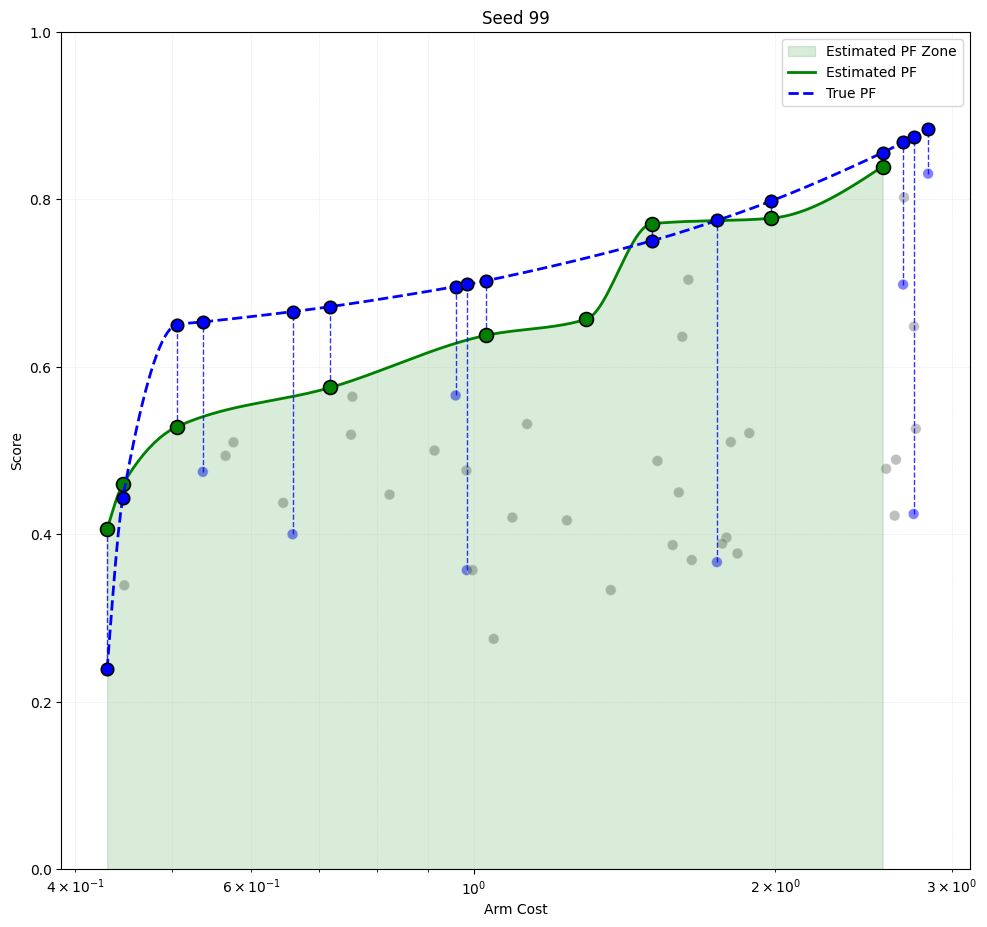

In [15]:
L=0.
fig, axes = plt.subplots(1, 1, figsize=(10, 10), sharey=True)
plot_frontier_panel(axes, data, true_df, seed=SEEDS[-1], lam=L)
axes.set_title(f"Seed {SEEDS[-1]}")
axes.set_xlabel("Arm Cost")
if idx % N_COLS == 0:
    ax.set_ylabel("Estimated Success Probability")
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [16]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 128
Average distinct arms called per seed: 5.45
Pareto quality (mean IGD): 0.1777
Average regret per pull: 0.1190
Average cost regret per pull: 0.2815
Average F1 Score:  0.4002


In [12]:
print(f"Number of API calls per seed: {avg_api_calls}")
print(f"Average distinct arms called per seed: {avg_arms_called:.2f}")
print(f"Pareto quality (mean IGD): {avg_igd:.4f}")
print(f"Average regret per pull: {avg_regret:.4f}")
print(f"Average cost regret per pull: {avg_costregret:.4f}")
print(f"Average F1 Score:  {np.mean(f1s):.4f}")

Number of API calls per seed: 128
Average distinct arms called per seed: 5.09
Pareto quality (mean IGD): 0.1580
Average regret per pull: 0.1136
Average cost regret per pull: 0.2740
Average F1 Score:  0.3744


Util: [0], Alpha: 120.0, Beta: 61.0, w = 0.9999999862193445
Util: [0], Alpha: 120.0, Beta: 61.0, w = 0.9999999862193445
Util: [4, 10], Alpha: 30.0, Beta: 27.0, w = 0.9966540345425288
Util: [2], Alpha: 5.0, Beta: 8.0, w = 0.7274682069659875
Util: [1, 2, 7, 8], Alpha: 20.0, Beta: 22.0, w = 0.9850044231795223
Util: [0], Alpha: 120.0, Beta: 61.0, w = 0.9999999862193445
Util: [4], Alpha: 16.0, Beta: 15.0, w = 0.9549507976064422
Util: [1, 4, 6, 10], Alpha: 40.0, Beta: 39.0, w = 0.9996292564595409
Util: [4, 5, 7, 8], Alpha: 34.0, Beta: 24.0, w = 0.9969724452546241
Util: [1, 3], Alpha: 11.999999999999996, Beta: 18.0, w = 0.950212931632136


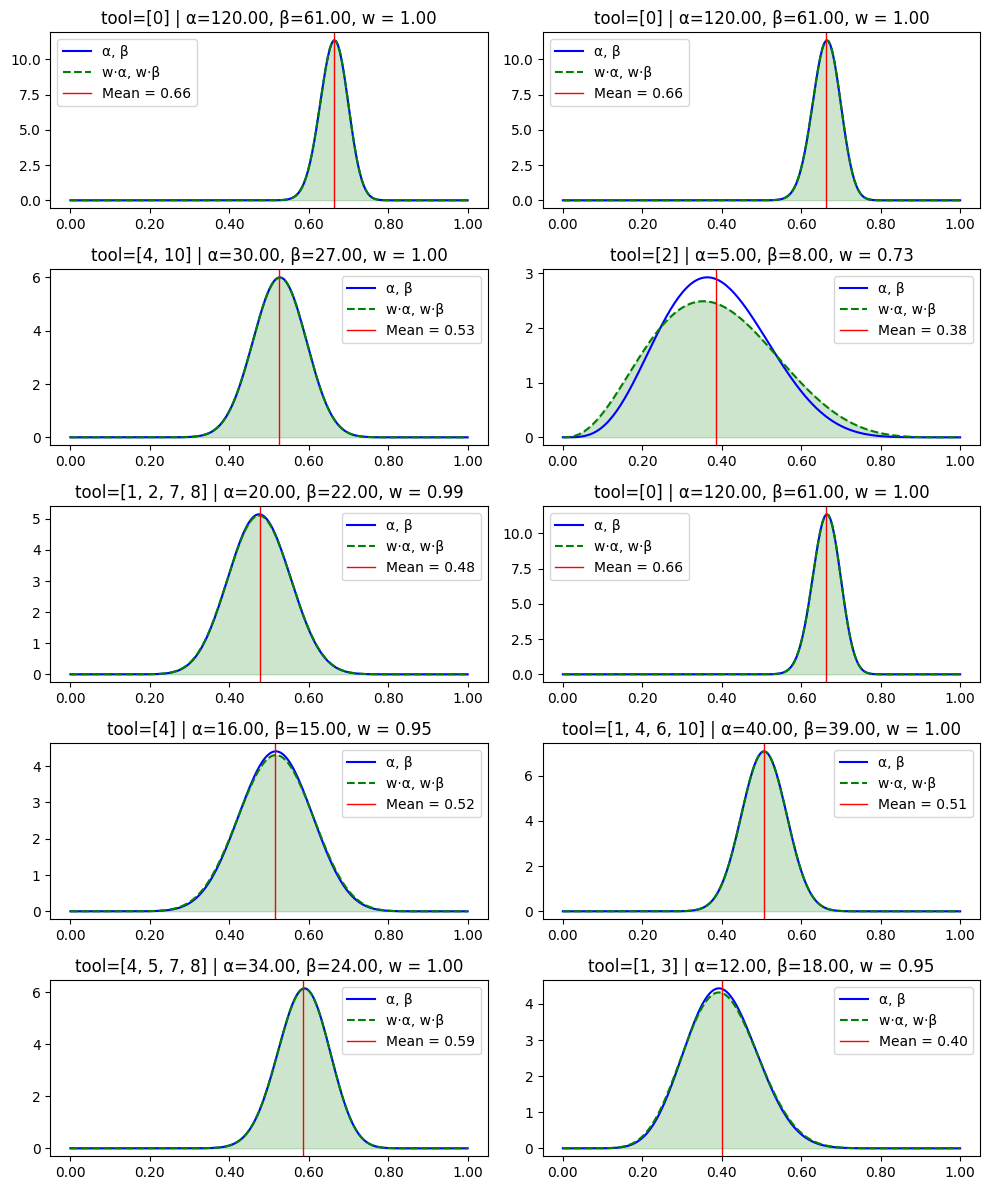

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.stats import beta

fig, axes = plt.subplots(5, 2, figsize=(10, 12))  # 5 rows × 2 cols
axes = axes.flatten()  # so we can index them easily

for idx, x in enumerate(range(10)):
    util = cluster_util[x] if cluster_util[x] != [] else [0]
    cartesian = list(itertools.product(util, repeat=2))
    unique_pairs = cartesian

    lalpha = [
        np.sum([np.tril(galpha, k=0)[m][pair] for pair in unique_pairs])
        for m in range(galpha.shape[0])
    ]
    lbeta = [
        np.sum([np.tril(gbeta, k=0)[m][pair] for pair in unique_pairs])
        for m in range(gbeta.shape[0])
    ]

    a = lalpha[49]
    b = lbeta[49]
    # w = 0.3
    n=a+b
   
    w = 1 - np.exp(-W * n)
    print(f"Util: {util}, Alpha: {a}, Beta: {b}, w = {w}")

    x_vals = np.linspace(0, 1, 200)

    # Base Beta PDF (blue)
    y_base = beta.pdf(x_vals, a, b)
    mean_base = a / (a + b)

    # Scaled Beta PDF (green)
    y_scaled = beta.pdf(x_vals, a * w, b * w)
    mean_scaled = (a * w) / ((a * w) + (b * w))

    ax = axes[idx]
    ax.plot(x_vals, y_base, color="blue", label="α, β")
    ax.plot(x_vals, y_scaled, color="green", linestyle="--", label=f"w·α, w·β")

    # Fill the area under scaled curve with green
    ax.fill_between(x_vals, y_scaled, color="green", alpha=0.2)

    # Add vertical lines for means, with legend labels
    ax.axvline(mean_base, color="red", linestyle="-", linewidth=1,
               label=f"Mean = {mean_base:.2f}")

    # Create ticks: regular 0.1 steps + mean positions
    base_ticks = np.round(np.arange(0, 1.01, 0.2), 2).tolist()
    special_ticks = sorted(set(base_ticks))
    ax.set_xticks(special_ticks)
    ax.set_xticklabels([f"{t:.2f}" for t in special_ticks])

    ax.set_title(f"tool={util} | α={a:.2f}, β={b:.2f}, w = {w:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()


Util: [0], Alpha: 56.0, Beta: 43.0
Util: [0], Alpha: 56.0, Beta: 43.0
Util: [4, 10], Alpha: 30.0, Beta: 29.0
Util: [2], Alpha: 5.0, Beta: 9.0
Util: [1, 2, 7, 8], Alpha: 25.0, Beta: 37.0
Util: [0], Alpha: 56.0, Beta: 43.0
Util: [4], Alpha: 12.0, Beta: 15.0
Util: [1, 4, 6, 10], Alpha: 46.0, Beta: 50.0
Util: [4, 5, 7, 8], Alpha: 24.0, Beta: 36.0
Util: [1, 3], Alpha: 8.0, Beta: 23.0


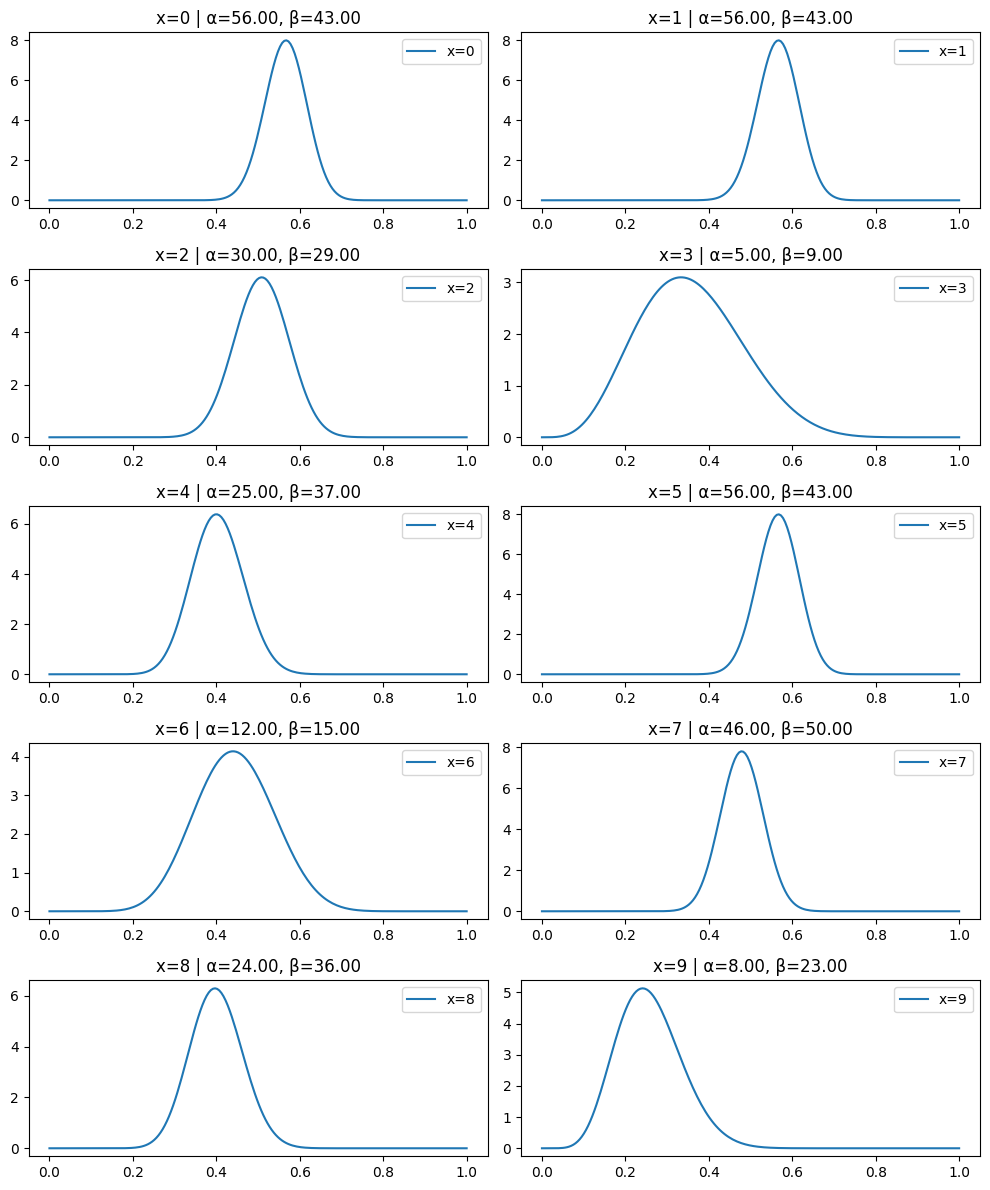

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.stats import beta

# Example: cluster_util, galpha, gbeta must be defined before this loop
# cluster_util = [...]
# galpha = np.random.rand(1000, 20, 20)  # just example
# gbeta = np.random.rand(1000, 20, 20)   # just example

fig, axes = plt.subplots(5, 2, figsize=(10, 12))  # 5 rows × 2 cols
axes = axes.flatten()  # so we can index them easily

for idx, x in enumerate(range(10)):
    util = cluster_util[x] if cluster_util[x] != [] else [0]
    cartesian = list(itertools.product(util, repeat=2))
    # unique_pairs = list({tuple(sorted(p)) for p in cartesian})
    unique_pairs = cartesian

    lalpha = [
        np.sum([np.tril(galpha, k=0)[m][pair] for pair in unique_pairs])
        for m in range(galpha.shape[0])
    ]
    lbeta = [
        np.sum([np.tril(gbeta, k=0)[m][pair] for pair in unique_pairs])
        for m in range(gbeta.shape[0])
    ]

    a = lalpha[999]
    b = lbeta[999]
    print(f"Util: {util}, Alpha: {a}, Beta: {b}")

    # Beta distribution PDF
    x_vals = np.linspace(0, 1, 200)
    y_vals = beta.pdf(x_vals, a, b)

    ax = axes[idx]
    ax.plot(x_vals, y_vals, label=f"x={x}")
    ax.set_title(f"x={x} | α={a:.2f}, β={b:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
galpha[999]

59.0

In [ ]:
gbeta[999]

73.0

Util: [1, 3], Alpha: 59.0, Beta: 73.0


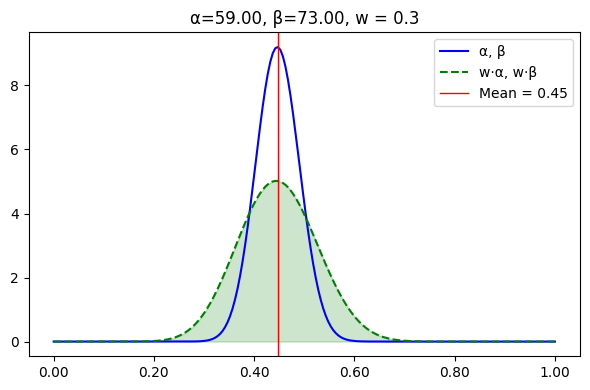

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.stats import beta

fig, ax = plt.subplots(1, 1, figsize=(6, 4))  # 10 rows × 2 cols

a = galpha[999]
b = gbeta[999]


print(f"Util: {util}, Alpha: {a}, Beta: {b}")

x_vals = np.linspace(0, 1, 200)
y_vals = beta.pdf(x_vals, a, b)


y_base = beta.pdf(x_vals, a, b)
mean_base = a / (a + b)

# Scaled Beta PDF (green)
y_scaled = beta.pdf(x_vals, a * w, b * w)
mean_scaled = (a * w) / ((a * w) + (b * w))
ax.plot(x_vals, y_base, color="blue", label="α, β")
ax.plot(x_vals, y_scaled, color="green", linestyle="--", label=f"w·α, w·β")

# Fill the area under scaled curve with green
ax.fill_between(x_vals, y_scaled, color="green", alpha=0.2)

# Add vertical lines for means, with legend labels
ax.axvline(mean_base, color="red", linestyle="-", linewidth=1,
            label=f"Mean = {mean_base:.2f}")

# Create ticks: regular 0.1 steps + mean positions
base_ticks = np.round(np.arange(0, 1.01, 0.2), 2).tolist()
special_ticks = sorted(set(base_ticks))
ax.set_xticks(special_ticks)
ax.set_xticklabels([f"{t:.2f}" for t in special_ticks])

ax.set_title(f"α={a:.2f}, β={b:.2f}, w = {w}")
ax.legend()

plt.tight_layout()
plt.show()
